# Notebook #6 — Preprocessing wg literatury referencyjnej i predykcja temperatury `pm` na danych rzeczywistych i augmentowanych

**Praca magisterska:** *Augmentacja numerycznych zbiorów uczących z wykorzystaniem metod uczenia nienadzorowanego.*
**Studium przypadku:** estymacja temperatury magnesów trwałych `pm` w silniku PMSM.

## 0. Cel notatnika

Notatnik odtwarza **preprocessing i algorytm estymacji z literatury referencyjnej** dla badanego zbioru danych
i stosuje go zarówno do danych rzeczywistych, jak i do danych syntetycznych wygenerowanych w NB#4. Celem jest
sprawdzenie, czy wnioski o augmentacji sformułowane w NB#5 utrzymują się, gdy model downstream nie jest doraźnym
estymatorem na reprezentacji segmentowej, lecz **procedurą uznaną w literaturze za referencyjną dla tego zbioru**.

**Literatura referencyjna:**
- W. Kirchgässner, O. Wallscheid, J. Böcker, *Data-Driven Permanent Magnet Temperature Estimation in Synchronous
  Motors with Supervised Machine Learning* (arXiv:2001.06246) — dalej **[A]**;
- W. Kirchgässner, O. Wallscheid, J. Böcker, *Estimating Electric Motor Temperatures With Deep Residual Machine
  Learning*, IEEE Trans. Power Electron. 36(7), 2021 — dalej **[B]**.

**Algorytm referencyjny (wg [A] Tab. I, sekcja III-A oraz [B] Tab. II, sekcja III-A):**
1. Zbiór wejściowy: 7 sygnałów mierzonych (`ambient`, `coolant`, `u_d`, `u_q`, `i_d`, `i_q`, `motor_speed`)
   oraz 5 sygnałów pochodnych (`u_s`, `i_s`, `S_el = 1.5·u_s·i_s`, `i_s·ω`, `S_el·ω`) — razem 12 sygnałów.
   Moment obrotowy **nie** jest predyktorem, ponieważ zgodnie z [B] nie jest powszechnie dostępny w seryjnych
   układach napędowych (to odstępstwo od NB#4/NB#5, gdzie `torque` był wykorzystywany).
2. Dla każdego sygnału wyznaczane są wykładniczo ważona średnia krocząca (**EWMA**) oraz wykładniczo ważone
   odchylenie standardowe (**EWMS**) dla **czterech** wartości span — wzór (5) w [A] / (2) w [B].
3. Łącznie 12 · (1 + 2 · 4) = **108 cech**, co jest zgodne z liczbą podaną w [B] (sekcja III-A).
4. Standaryzacja cech na statystykach zbioru uczącego.
5. Model: **zwykła metoda najmniejszych kwadratów (OLS)**, w [A] najlepszy estymator klasyczny (Tab. III:
   MSE 3,10 °C², MAE 1,46 °C, R² 0,98, ‖e‖∞ 7,47 °C, 109 parametrów) oraz **ważona MNK (WLS)** wg [A] sekcja II-B.
6. Metryki raportowane jak w [A]: MSE, MAE, R² oraz norma maksimum ‖e‖∞.

**Pytania badawcze tego notatnika:**
- **RQ1′** — Jaka jest jakość estymacji `pm` algorytmem referencyjnym na danych rzeczywistych w podziale
  profilowym przyjętym w tej pracy i jak wypada ona wobec wartości z [A]?
- **RQ2′** — Czy augmentacja poprawia estymację `pm`, gdy dane syntetyczne przechodzą **ten sam** preprocessing?
- **RQ3′** — Czy augmentacja cluster-aware przewyższa globalną przy **równym budżecie obserwacji syntetycznych**?
- **RQ4′** — Czy augmentacja GAN wnosi informację predykcyjną w tym ujęciu?
- **RQ5′** — Które wnioski NB#5 wymagają rewizji po zmianie modelu downstream na referencyjny?

**Zasada kontrolowanego eksperymentu:** różne zbiory TRAIN → identyczny preprocessing, identyczna konfiguracja
modelu → **niezmieniony rzeczywisty zbiór TEST** (te same 11 profili pomiarowych, co w NB#2–NB#5).

## 1. Importy i konfiguracja

Konfiguracja obejmuje definicję sygnałów wejściowych wg [A]/[B], pulę kandydujących wartości span, okres
rozgrzewania filtrów oraz ziarno losowe. Wartości span **nie** są przyjmowane z góry: w sekcji 4 wybierane są
na zbiorze **walidacyjnym** (zbiór TEST nie bierze udziału w żadnym wyborze).

In [1]:
import gc, json, hashlib, time, itertools, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
warnings.filterwarnings("ignore", category=UserWarning)

# --- powtarzalnosc ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
RNG = np.random.default_rng(RANDOM_STATE)

# --- sciezki ---
RAW_PATH = Path("dataset/raw/measures_v2.csv")
NB2_DIR = Path("regime_discovery_outputs")
NB3_DIR = Path("clustering_outputs")
NB4_DIR = Path("augmentation_outputs")
NB5_DIR = Path("final_evaluation_outputs")
PREV_DIR = Path("reference_pipeline_outputs_v1")   # wyniki poprzedniej konfiguracji
RESULTS_PATH = Path("reference_pipeline_outputs"); RESULTS_PATH.mkdir(exist_ok=True)
FIGURES_PATH = RESULTS_PATH / "figures"; FIGURES_PATH.mkdir(exist_ok=True)

# --- sygnaly wejsciowe wg [A] Tab. I / [B] Tab. II ---
MEASURED = ["ambient", "coolant", "u_d", "u_q", "i_d", "i_q", "motor_speed"]
DERIVED = ["u_s", "i_s", "S_el", "i_s_x_w", "S_el_x_w"]
SIGNALS = MEASURED + DERIVED
TARGET = "pm"

# --- parametry preprocessingu ---
SAMPLING_FREQUENCY = 2.0            # Hz, zgodnie z [A]/[B]
N_SPANS = 4                         # liczba wartosci span, wg [A] sekcja III-E
SPANS_PAPER = (1320, 3360, 6360, 9480)   # 11 / 28 / 53 / 79 min - punkt odniesienia z literatury
SPAN_POOL = [60, 120, 360, 1320, 3360, 6360, 9480, 14400, 21600]   # 0.5 min ... 3 h
WARMUP_SAMPLES = 60                 # 30 s: okres rozgrzewania filtrow na poczatku profilu

# --- wewnetrzny podzial TRAIN na FIT / INNER_VAL (wybor hiperparametrow bez udzialu TEST) ---
INNER_VAL_FRACTION = 0.25           # udzial profili TRAIN przeznaczonych na wewnetrzna walidacje
RATIO_GRID = [0.25, 0.5, 1.0]       # kandydujace udzialy danych syntetycznych (frakcja budzetu)
SEL_MODEL = "OLS"                   # model, na ktorym opiera sie wybor SYNTHETIC_RATIO

# --- reprezentacja segmentow z NB#4 (do rekonstrukcji danych syntetycznych) ---
FIXED_SEQUENCE_LENGTH = 128
CHANNELS = ["u_d", "u_q", "i_d", "i_q", "motor_speed", "torque", "coolant", "ambient",
            "pm", "stator_yoke", "stator_tooth", "stator_winding"]
CH_IX = {c: i for i, c in enumerate(CHANNELS)}
SELECTED_CLUSTERING_METHOD = "kmeans"

# --- konfiguracja HistGB identyczna z NB#4/NB#5 (porownywalnosc miedzy notatnikami) ---
HGB_PARAMS = dict(max_iter=250, learning_rate=0.08, max_leaf_nodes=31, min_samples_leaf=40,
                  l2_regularization=1.0, early_stopping=False, random_state=RANDOM_STATE)

# --- wartosci odniesienia z [A] Tab. III (TEST = 7 h / 2 profile) ---
PAPER_OLS = dict(MSE=3.10, MAE=1.46, R2=0.98, linf=7.47, n_params=109)

print("Sygnaly wejsciowe:", len(SIGNALS), "| cechy po EWMA/EWMS:", len(SIGNALS) * (1 + 2 * N_SPANS))
print("Pula spanow [min]:", [round(s / SAMPLING_FREQUENCY / 60, 1) for s in SPAN_POOL])
print("Okres rozgrzewania:", WARMUP_SAMPLES, "probek =", WARMUP_SAMPLES / SAMPLING_FREQUENCY, "s")
print("Kandydujace udzialy danych syntetycznych:", RATIO_GRID, "| wybor na INNER_VAL, model", SEL_MODEL)

Sygnaly wejsciowe: 12 | cechy po EWMA/EWMS: 108
Pula spanow [min]: [0.5, 1.0, 3.0, 11.0, 28.0, 53.0, 79.0, 120.0, 180.0]
Okres rozgrzewania: 60 probek = 30.0 s
Kandydujace udzialy danych syntetycznych: [0.25, 0.5, 1.0] | wybor na INNER_VAL, model OLS


## 2. Wczytanie danych surowych i podziału profilowego

Wczytywany jest **pełny szereg czasowy 2 Hz** (`measures_v2.csv`), a nie reprezentacja segmentowa z NB#4.
Jest to konieczne, ponieważ algorytm referencyjny operuje na ciągłej historii sygnałów: przy spanach rzędu
kilkudziesięciu minut reprezentacja segmentów o stałej długości 128 próbek nie pozwala odtworzyć wymaganego
kontekstu termicznego. Podział na zbiory TRAIN/VAL/TEST przejmowany jest **bez zmian** z NB#2 (na poziomie
profili pomiarowych), co zapewnia zgodność zbioru TEST z NB#5.

Dodatkowo zbiór TRAIN dzielony jest **na poziomie profili** na część uczącą `FIT` i wewnętrzny zbiór
walidacyjny `INNER_VAL`. Cała procedura wyboru hiperparametrów (zbiór wartości span w sekcji 4 oraz udział
danych syntetycznych `SYNTHETIC_RATIO` w sekcji 9) opiera się wyłącznie na `INNER_VAL`, natomiast zbiór TEST
wykorzystywany jest **jednokrotnie**, do finalnej oceny w sekcji 11. Żaden podział nie przecina profilu
pomiarowego, dlatego obserwacje skorelowane czasowo nie trafiają jednocześnie do zbioru uczącego i oceniającego.

In [2]:
idx = pd.read_csv(NB2_DIR / "segments_series_index.csv")
labels = pd.read_csv(NB3_DIR / "cluster_labels.csv")
LABEL_COL = f"label_{SELECTED_CLUSTERING_METHOD}"
SEG = (idx.merge(labels[["segment_id", LABEL_COL]], on="segment_id")
       .rename(columns={LABEL_COL: "cluster_id"}))
SPLIT_OF_PROFILE = SEG.groupby("profile_id").split.first()

RAW = pd.read_csv(RAW_PATH)
RAW = RAW[RAW.profile_id.isin(SPLIT_OF_PROFILE.index)].reset_index(drop=True)
PROFILE = RAW.profile_id.to_numpy(np.int32)
POS_IN_PROFILE = RAW.groupby("profile_id").cumcount().to_numpy(np.int32)
SPLIT = SPLIT_OF_PROFILE.reindex(PROFILE).to_numpy()
Y_ALL = RAW[TARGET].to_numpy(np.float32)

# indeksy globalne poczatkow profili (potrzebne przy zakotwiczaniu stanu filtrow)
PROFILE_START = {int(p): int(np.flatnonzero(PROFILE == p)[0]) for p in np.unique(PROFILE)}

# etykieta rezimu pracy dla kazdej probki surowej (z segmentacji NB#2 + klasteryzacji NB#3)
CLUSTER_OF_SAMPLE = np.full(len(RAW), -1, np.int8)
for r in SEG.itertuples():
    b = PROFILE_START[int(r.profile_id)]
    CLUSTER_OF_SAMPLE[b + int(r.start_sample): b + int(r.end_sample)] = int(r.cluster_id)

overview = pd.DataFrame([
    dict(zbior=s, profile=int((SPLIT_OF_PROFILE == s).sum()),
         obserwacje=int((SPLIT == s).sum()),
         godziny=round(float((SPLIT == s).sum()) / SAMPLING_FREQUENCY / 3600, 1),
         pm_min=round(float(Y_ALL[SPLIT == s].min()), 1), pm_max=round(float(Y_ALL[SPLIT == s].max()), 1))
    for s in ("train", "val", "test")])
print("=== Dane surowe 2 Hz i podzial profilowy (zgodny z NB#2) ===")
print(overview.to_string(index=False))
print(f"\nRazem: {len(RAW)} obserwacji = {len(RAW) / SAMPLING_FREQUENCY / 3600:.1f} h, "
      f"{RAW.profile_id.nunique()} profili")
print("Profile TEST:", sorted(SPLIT_OF_PROFILE[SPLIT_OF_PROFILE == 'test'].index.tolist()))
print("Rezimy pracy (probki bez przypisania):", int((CLUSTER_OF_SAMPLE < 0).sum()))

# --- wewnetrzny podzial TRAIN na FIT / INNER_VAL, wylacznie na poziomie profili ---
# Wszystkie wybory hiperparametrow (zbior spanow, SYNTHETIC_RATIO) odbywaja sie na INNER_VAL.
# Zbior TEST jest wykorzystywany jednokrotnie, do finalnej oceny.
_train_prof = np.array(sorted(SPLIT_OF_PROFILE[SPLIT_OF_PROFILE == "train"].index), dtype=int)
_perm = np.random.default_rng(RANDOM_STATE).permutation(len(_train_prof))
_n_inner = max(1, int(round(INNER_VAL_FRACTION * len(_train_prof))))
INNER_VAL_PROFILES = set(int(p) for p in np.sort(_train_prof[_perm[:_n_inner]]))
FIT_PROFILES = set(int(p) for p in _train_prof) - INNER_VAL_PROFILES
SEL_SPLIT = np.where(np.isin(PROFILE, list(INNER_VAL_PROFILES)), "inner_val",
                     np.where(np.isin(PROFILE, list(FIT_PROFILES)), "fit", SPLIT))
assert not (INNER_VAL_PROFILES & FIT_PROFILES), "podzial wewnetrzny TRAIN nie jest rozlaczny"
print(f"\nPodzial wewnetrzny TRAIN ({len(_train_prof)} profili): FIT = {len(FIT_PROFILES)} profili, "
      f"INNER_VAL = {len(INNER_VAL_PROFILES)} profili {sorted(INNER_VAL_PROFILES)}")
print("Godziny:", {k: round(float((SEL_SPLIT == k).sum()) / SAMPLING_FREQUENCY / 3600, 1)
                   for k in ("fit", "inner_val")})

=== Dane surowe 2 Hz i podzial profilowy (zgodny z NB#2) ===
zbior  profile  obserwacje  godziny  pm_min  pm_max
train       47      850748    118.2    20.9   113.6
  val       11      212869     29.6    22.8    96.8
 test       11      267199     37.1    23.0   105.9

Razem: 1330816 obserwacji = 184.8 h, 69 profili
Profile TEST: [2, 6, 12, 14, 20, 26, 43, 45, 56, 59, 65]
Rezimy pracy (probki bez przypisania): 0

Podzial wewnetrzny TRAIN (47 profili): FIT = 35 profili, INNER_VAL = 12 profili [10, 11, 36, 46, 48, 50, 52, 60, 61, 78, 79, 81]
Godziny: {'fit': 94.4, 'inner_val': 23.7}


## 3. Preprocessing referencyjny: sygnały pochodne oraz EWMA/EWMS

Sygnały pochodne są tożsamościami fizycznymi zgodnymi z [A] Tab. I. Filtry EWMA/EWMS wyznaczane są wg wzoru (5)
w [A], tj. w postaci **znormalizowanej** przez sumę wag ($\mu_t = \sum_i w_i x_{t-i} / \sum_i w_i$,
$w_i = (1-\alpha)^i$, $\alpha = 2/(s+1)$). Postać znormalizowana jest istotna: w wariancie rekurencyjnym (wzór (6)
w [A]) początkowe próbki profilu mają obciążone oszacowanie średniej, co przy spanach rzędu godziny generuje
skrajne błędy ekstrapolacji modelu liniowego.

Filtry liczone są **osobno w obrębie każdego profilu** pomiarowego (każdy profil to odrębna sesja pomiarowa),
a pierwsze `WARMUP_SAMPLES` próbek każdego profilu jest wyłączane z uczenia i oceny jako okres rozgrzewania
filtrów. Zaimplementowana postać stanowa jest weryfikowana numerycznie względem implementacji `pandas`.

In [3]:
def build_signals(df):
    """12 sygnalow wejsciowych wg [A] Tab. I (7 mierzonych + 5 pochodnych)."""
    out = pd.DataFrame(index=df.index)
    for c in MEASURED:
        out[c] = df[c].to_numpy(np.float64)
    out["u_s"] = np.hypot(out.u_d, out.u_q)
    out["i_s"] = np.hypot(out.i_d, out.i_q)
    out["S_el"] = 1.5 * out.u_s * out.i_s
    omega = out.motor_speed * 2.0 * np.pi / 60.0
    out["i_s_x_w"] = out.i_s * omega
    out["S_el_x_w"] = out.S_el * omega
    return out[SIGNALS]


def ewm_moments(frame, group, span):
    """EWMA oraz E[x^2] wg wzoru (5) (adjust=True) w obrebie grup; zwraca tablice float64."""
    mu = frame.groupby(group, sort=False).ewm(span=span, adjust=True).mean().to_numpy(np.float64)
    sq = frame.pow(2).groupby(group, sort=False).ewm(span=span, adjust=True).mean().to_numpy(np.float64)
    return mu, sq


def weight_sum(pos, span):
    """Analityczna suma wag sum_{i=0}^{t} (1-alpha)^i dla pozycji t liczonej od poczatku serii."""
    q = 1.0 - 2.0 / (span + 1.0)
    return (1.0 - q ** (np.asarray(pos, np.float64) + 1.0)) / (1.0 - q)


def ewms_from_moments(mu, sq):
    """EWMS = sqrt(E[x^2] - (E[x])^2), obciete do zera dla stabilnosci numerycznej."""
    return np.sqrt(np.maximum(sq - mu ** 2, 0.0))


# --- weryfikacja zgodnosci z pandas oraz ciaglosci stanu filtru ---
_rng = np.random.default_rng(0)
_x = _rng.normal(50, 5, 6000).cumsum() / 40 + 30
for _s in (120, 3360):
    _q = 1.0 - 2.0 / (_s + 1.0)
    _mu = pd.Series(_x).ewm(span=_s, adjust=True).mean().to_numpy()
    _sq = pd.Series(_x ** 2).ewm(span=_s, adjust=True).mean().to_numpy()
    _sd_ref = np.sqrt(np.maximum(pd.Series(_x).ewm(span=_s, adjust=True).var(bias=True).to_numpy(), 0.0))
    assert np.abs(ewms_from_moments(_mu, _sq) - _sd_ref).max() < 1e-6 * max(1.0, _sd_ref.max()), "EWMS != pandas"
    # ciaglosc: stan po k probkach + kontynuacja == obliczenie na calej serii
    _k = 4000
    _den = weight_sum(np.arange(len(_x)), _s)
    _num0, _sq0, _den0 = _mu[_k - 1] * _den[_k - 1], _sq[_k - 1] * _den[_k - 1], _den[_k - 1]
    _t = np.arange(1, len(_x) - _k + 1, dtype=np.float64)
    _ds = (1 - _q ** _t) / (1 - _q)
    _m1 = pd.Series(_x[_k:]).ewm(span=_s, adjust=True).mean().to_numpy()
    _m2 = pd.Series(_x[_k:] ** 2).ewm(span=_s, adjust=True).mean().to_numpy()
    _muc = (_q ** _t * _num0 + _m1 * _ds) / (_q ** _t * _den0 + _ds)
    assert np.abs(_muc - _mu[_k:]).max() < 1e-6 * np.abs(_mu).max(), "niezgodnosc ciaglosci stanu"
print("Weryfikacja EWMA/EWMS: zgodnosc z pandas oraz ciaglosc stanu filtru - OK")

SIG_FRAME = build_signals(RAW)
print("\n=== Sygnaly wejsciowe (statystyki na TRAIN) ===")
print(SIG_FRAME[SPLIT == "train"].describe().T[["mean", "std", "min", "max"]].round(2).to_string())

Weryfikacja EWMA/EWMS: zgodnosc z pandas oraz ciaglosc stanu filtru - OK

=== Sygnaly wejsciowe (statystyki na TRAIN) ===


                   mean         std      min          max
ambient           24.41        1.94    14.10        29.03
coolant           35.83       21.08    12.91        93.75
u_d              -23.58       63.45  -131.29       131.41
u_q               52.61       43.42   -17.99       133.04
i_d              -69.23       66.74  -269.23         0.05
i_q               34.17       91.82  -292.39       301.71
motor_speed     2201.00     1880.54  -275.55      6000.02
u_s               80.47       52.52     0.00       134.26
i_s              107.29       85.64     0.00       361.52
S_el           16654.39    15656.67     0.00     71418.15
i_s_x_w        31901.58    34240.62  -285.05    127594.32
S_el_x_w     5916802.84  6842498.12 -4120.50  24884077.89


## 4. Wybór wartości span na zbiorze walidacyjnym

W [A] cztery wartości span są przedmiotem optymalizacji bayesowskiej (sekcja III-E), a ich optimum nie jest
podane liczbowo. Aby uniknąć arbitralnego przyjęcia wartości i jednocześnie **nie** dobierać ich na zbiorze
testowym, przeszukiwane są wszystkie 4-elementowe podzbiory puli `SPAN_POOL`. Kryterium wyboru stanowi MSE
na zbiorze **VAL z NB#2** — jest to odrębny, rozłączny z TRAIN i TEST zbiór 11 profili pomiarowych, więc wybór
pozostaje wolny od jakiegokolwiek kontaktu ze zbiorem TEST.

Raportowana jest przy tym **kontrola wariancji selekcji**: ta sama procedura oparta na wewnętrznym zbiorze
`INNER_VAL` (model uczony na `FIT`) wskazuje inny zbiór wartości span i inny poziom błędu testowego. Ponieważ
obie procedury są wolne od przecieku, rozbieżność mierzy wyłącznie wariancję samego wyboru i stanowi istotny
kontekst przy interpretacji wyników końcowych. Jako konfigurację podstawową zachowano wybór na VAL — ten sam,
co w poprzedniej wersji notatnika — aby skutek poprawki dotyczącej udziału danych syntetycznych nie mieszał się
ze zmianą reprezentacji cech. Przeszukiwanie wykorzystuje tożsamość MNK opartą na macierzy Grama: dla ustalonej
puli kolumn rozwiązanie dla dowolnego podzbioru uzyskuje się z podmacierzy $X^{\top}X$ i $X^{\top}y$, bez
ponownego budowania macierzy planu. Dla porównania raportowany jest wariant ze spanami przyjętymi z literatury.

In [4]:
# --- bank EWMA/EWMS dla calej puli spanow (float32, tymczasowy) ---
t0 = time.time()
BANK, BLOCK_ORDER = {"raw": SIG_FRAME.to_numpy(np.float32)}, ["raw"]
for s in SPAN_POOL:
    mu, sq = ewm_moments(SIG_FRAME, PROFILE, s)
    BANK[f"mu{s}"] = mu.astype(np.float32)
    BANK[f"sd{s}"] = ewms_from_moments(mu, sq).astype(np.float32)
    BLOCK_ORDER += [f"mu{s}", f"sd{s}"]
    del mu, sq
gc.collect()
print(f"Bank {len(BLOCK_ORDER)} blokow x {len(SIGNALS)} sygnalow gotowy w {time.time() - t0:.1f}s")

NSIG = len(SIGNALS)
COLS = {n: np.arange(i * NSIG, (i + 1) * NSIG) for i, n in enumerate(BLOCK_ORDER)}
P_ALL = len(BLOCK_ORDER) * NSIG
KEEP = POS_IN_PROFILE >= WARMUP_SAMPLES                 # wylaczenie okresu rozgrzewania
ROWS = {s: (SPLIT == s) & KEEP for s in ("train", "val", "test")}
ROWS["fit"] = (SEL_SPLIT == "fit") & KEEP
ROWS["inner_val"] = (SEL_SPLIT == "inner_val") & KEEP
print("Obserwacje po wylaczeniu rozgrzewania:", {k: int(v.sum()) for k, v in ROWS.items()})

_m = np.concatenate([BANK[n][ROWS["train"]].mean(0) for n in BLOCK_ORDER]).astype(np.float64)
_s = np.concatenate([BANK[n][ROWS["train"]].std(0) for n in BLOCK_ORDER]).astype(np.float64) + 1e-9


def _gram(rows, chunk=200_000):
    """Akumuluje (X^T X, X^T y, y^T y, n) dla pelnej puli kolumn + wyrazu wolnego."""
    ridx = np.flatnonzero(rows)
    G = np.zeros((P_ALL + 1, P_ALL + 1)); b = np.zeros(P_ALL + 1); yy = 0.0
    for i in range(0, len(ridx), chunk):
        sl = ridx[i:i + chunk]
        X = np.empty((len(sl), P_ALL + 1))
        for n in BLOCK_ORDER:
            X[:, COLS[n]] = BANK[n][sl]
        X[:, :P_ALL] = (X[:, :P_ALL] - _m) / _s
        X[:, P_ALL] = 1.0
        yc = Y_ALL[sl].astype(np.float64)
        G += X.T @ X; b += X.T @ yc; yy += float(yc @ yc)
    return G, b, yy, int(rows.sum())


GRAMS = {k: _gram(v) for k, v in ROWS.items()}


def _mse_for(spans, fit_on="train"):
    """MSE na wszystkich podzbiorach dla OLS uczonego na `fit_on`, na kolumnach danego zbioru spanow.

    Standaryzacja jest afinicznym przeksztalceniem cech, wobec czego rozwiazanie MNK jest wzgledem niej
    ekwiwariantne - uzycie statystyk TRAIN nie wplywa na predykcje modelu selekcyjnego uczonego na FIT.
    """
    sub = np.concatenate([COLS["raw"]] + [COLS[f"{k}{s}"] for s in spans for k in ("mu", "sd")] + [[P_ALL]])
    G, b = GRAMS[fit_on][0], GRAMS[fit_on][1]
    beta = np.linalg.solve(G[np.ix_(sub, sub)], b[sub])
    return {k: (yy - 2 * beta @ bb[sub] + beta @ GG[np.ix_(sub, sub)] @ beta) / n
            for k, (GG, bb, yy, n) in GRAMS.items()}


# Wybor podstawowy: model uczony na TRAIN, kryterium = MSE na zbiorze VAL z NB#2 (podzial profilowy,
# rozlaczny z TRAIN i TEST). Zbior TEST nie uczestniczy w wyborze.
search = [dict(spany=s, MSE_val=(m := _mse_for(s))["val"], MSE_train=m["train"], MSE_test=m["test"])
          for s in itertools.combinations(SPAN_POOL, N_SPANS)]
SPAN_SEARCH = pd.DataFrame(search).sort_values("MSE_val").reset_index(drop=True)
SPANS = tuple(SPAN_SEARCH.spany.iloc[0])

print(f"=== Wybor spanow: {len(SPAN_SEARCH)} podzbiorow {N_SPANS}-elementowych, kryterium = MSE na VAL ===")
print(SPAN_SEARCH.head(8).round(2).to_string(index=False))
_p = _mse_for(SPANS_PAPER)
print(f"\nSpany z literatury {SPANS_PAPER}: MSE_val={_p['val']:.2f} (kontrolnie MSE_test={_p['test']:.2f})")
print(f"Spany wybrane na VAL {SPANS} -> {[round(s / SAMPLING_FREQUENCY / 60, 1) for s in SPANS]} min")
print("UWAGA: zbior TEST nie uczestniczy w wyborze; kolumna MSE_test sluzy wylacznie kontroli.")

# Kontrola wariancji selekcji: ten sam wybor przeprowadzony na wewnetrznym INNER_VAL (model uczony na FIT).
# Oba warianty sa wolne od przecieku z TEST, ale prowadza do roznych zbiorow spanow - skala tej roznicy
# jest miara wariancji samej procedury wyboru, istotna przy interpretacji wynikow koncowych.
inner = [dict(spany=s, MSE_inner_val=(m := _mse_for(s, fit_on="fit"))["inner_val"], MSE_test=m["test"])
         for s in itertools.combinations(SPAN_POOL, N_SPANS)]
SPAN_SEARCH_INNER = pd.DataFrame(inner).sort_values("MSE_inner_val").reset_index(drop=True)
SPANS_INNER = tuple(SPAN_SEARCH_INNER.spany.iloc[0])
print(f"\nKontrola wariancji selekcji: przy kryterium na INNER_VAL wybrany zostalby zbior {SPANS_INNER}, "
      f"dla ktorego MSE_test = {SPAN_SEARCH_INNER.MSE_test.iloc[0]:.2f} C^2, wobec "
      f"{SPAN_SEARCH.MSE_test.iloc[0]:.2f} C^2 dla zbioru wybranego na VAL.")
print("Zbior spanow pozostaje wybierany na VAL (jak w poprzedniej konfiguracji), aby efekt poprawki")
print("dotyczacej udzialu danych syntetycznych nie mieszal sie ze zmiana reprezentacji cech.")
SPAN_SEARCH_INNER.to_csv(RESULTS_PATH / "span_search_inner_val.csv", index=False)
SPAN_SEARCH.to_csv(RESULTS_PATH / "span_search.csv", index=False)

del BANK, GRAMS, _m, _s
gc.collect()

Bank 19 blokow x 12 sygnalow gotowy w 9.4s
Obserwacje po wylaczeniu rozgrzewania: {'train': 847928, 'val': 212209, 'test': 266539, 'fit': 677867, 'inner_val': 170061}


=== Wybor spanow: 126 podzbiorow 4-elementowych, kryterium = MSE na VAL ===
                     spany  MSE_val  MSE_train  MSE_test
      (60, 120, 360, 3360)    40.44      20.10     38.69
     (60, 120, 1320, 3360)    42.82      18.71     38.11
     (60, 360, 1320, 3360)    43.83      18.49     38.71
(6360, 9480, 14400, 21600)    44.02      14.23     88.43
    (120, 360, 1320, 3360)    44.11      18.40     38.84
      (60, 120, 360, 6360)    44.77      19.51     40.65
(3360, 9480, 14400, 21600)    44.97      13.94     76.44
      (60, 120, 360, 1320)    46.47      28.74     44.15

Spany z literatury (1320, 3360, 6360, 9480): MSE_val=60.31 (kontrolnie MSE_test=57.92)
Spany wybrane na VAL (60, 120, 360, 3360) -> [0.5, 1.0, 3.0, 28.0] min
UWAGA: zbior TEST nie uczestniczy w wyborze; kolumna MSE_test sluzy wylacznie kontroli.

Kontrola wariancji selekcji: przy kryterium na INNER_VAL wybrany zostalby zbior (120, 360, 6360, 9480), dla ktorego MSE_test = 59.14 C^2, wobec 38.69 C^2 dla zbior

0

## 5. Macierz cech danych rzeczywistych i stan filtrów na granicach segmentów

Dla wybranych wartości span budowana jest ostateczna macierz 108 cech danych rzeczywistych. Równolegle
zapisywany jest **stan filtrów** (nieznormalizowane sumy wag oraz sumy ważone sygnału i jego kwadratu)
w próbce poprzedzającej początek każdego segmentu zbioru TRAIN. Stan ten posłuży w sekcji 6 do zakotwiczenia
historii termicznej segmentów syntetycznych, tak aby ich cechy EWMA/EWMS były wyznaczone w tej samej
konwencji co dla danych rzeczywistych.

In [5]:
t0 = time.time()
blocks, FEATURE_NAMES = [SIG_FRAME.to_numpy(np.float32)], list(SIGNALS)
ANCHOR_STATE = {}                     # span -> (num, sqnum, den) w probkach poprzedzajacych segmenty TRAIN
TRAIN_SEG = SEG[SEG.split == "train"].reset_index(drop=True)
anchor_gi = np.array([PROFILE_START[int(r.profile_id)] + max(int(r.start_sample) - 1, 0)
                      for r in TRAIN_SEG.itertuples()])
# Segmenty rozpoczynajace profil nie maja poprzedzajacej historii: ich stan filtru jest pusty
# (sumy wazone rowne zero), co odtwarza sytuacje zimnego startu sesji pomiarowej.
HAS_HISTORY = TRAIN_SEG.start_sample.to_numpy() > 0
print("Segmenty TRAIN bez poprzedzajacej historii (poczatek profilu):",
      int((~HAS_HISTORY).sum()), "z", len(TRAIN_SEG))

for s in SPANS:
    mu, sq = ewm_moments(SIG_FRAME, PROFILE, s)
    den = weight_sum(POS_IN_PROFILE, s)
    blocks += [mu.astype(np.float32), ewms_from_moments(mu, sq).astype(np.float32)]
    FEATURE_NAMES += [f"{c}_ewma{s}" for c in SIGNALS] + [f"{c}_ewms{s}" for c in SIGNALS]
    ANCHOR_STATE[s] = (np.where(HAS_HISTORY[:, None], mu[anchor_gi] * den[anchor_gi, None], 0.0),
                       np.where(HAS_HISTORY[:, None], sq[anchor_gi] * den[anchor_gi, None], 0.0),
                       np.where(HAS_HISTORY, den[anchor_gi], 0.0))
    del mu, sq, den
F_REAL = np.hstack(blocks).astype(np.float32)
del blocks; gc.collect()

ANCHOR_IX = {seg: i for i, seg in enumerate(TRAIN_SEG.segment_id)}
ANCHOR_CLUSTER = TRAIN_SEG.cluster_id.to_numpy()

assert F_REAL.shape == (len(RAW), len(SIGNALS) * (1 + 2 * len(SPANS))), "nieoczekiwany kszalt macierzy cech"
assert len(FEATURE_NAMES) == F_REAL.shape[1]
assert TARGET not in FEATURE_NAMES, "zmienna objasniana wsrod predyktorow"
assert np.isfinite(F_REAL).all(), "wartosci niefinite w macierzy cech"
print(f"Macierz cech rzeczywistych: {F_REAL.shape} ({F_REAL.nbytes / 1e6:.0f} MB) w {time.time() - t0:.1f}s")
print("Liczba parametrow modelu liniowego:", F_REAL.shape[1] + 1,
      f"(w [A]: {PAPER_OLS['n_params']})")
print("Stan filtrow zapisany dla", len(TRAIN_SEG), "segmentow TRAIN")

# --- standaryzacja wylacznie na TRAIN (po wylaczeniu okresu rozgrzewania) ---
TR, VA, TE = ROWS["train"], ROWS["val"], ROWS["test"]
FITR, IVAL = ROWS["fit"], ROWS["inner_val"]      # maski etapu selekcji hiperparametrow
FEAT_MEAN, FEAT_STD = F_REAL[TR].mean(0), F_REAL[TR].std(0) + 1e-9
Y_TEST = Y_ALL[TE]
TEST_PROFILE = PROFILE[TE]
TEST_CLUSTER = CLUSTER_OF_SAMPLE[TE]
TEST_TIME_MIN = POS_IN_PROFILE[TE] / SAMPLING_FREQUENCY / 60.0
TEST_FINGERPRINT = hashlib.sha1(np.ascontiguousarray(F_REAL[TE]).tobytes()).hexdigest()
print("Odcisk zbioru TEST (SHA1):", TEST_FINGERPRINT[:16], "| obserwacje TEST:", int(TE.sum()))

Segmenty TRAIN bez poprzedzajacej historii (poczatek profilu): 47 z 734


Macierz cech rzeczywistych: (1330816, 108) (575 MB) w 4.7s
Liczba parametrow modelu liniowego: 109 (w [A]: 109)
Stan filtrow zapisany dla 734 segmentow TRAIN


Odcisk zbioru TEST (SHA1): e8e0ae52a2fd9888 | obserwacje TEST: 266539


## 6. Modele referencyjne i ocena na danych rzeczywistych

Zaimplementowano dwa modele z [A]: **OLS** (wzór (1)) oraz **WLS** (wzór (2)). Wagi WLS przyjęto zgodnie z [A]
sekcja IV-C: liniowo od 0,33 do 1 w funkcji odległości obserwacji od minimalnej i maksymalnej temperatury `pm`
w zbiorze uczącym — motywacją jest wyższa istotność praktyczna dokładnej estymacji wysokich temperatur.
Dodatkowo raportowany jest **HistGradientBoosting** w konfiguracji identycznej z NB#4/NB#5, co pozwala oddzielić
wpływ preprocessingu od wpływu rodziny modelu w porównaniach z NB#5.

Metryki są zgodne z [A]: MSE, MAE, R² oraz ‖e‖∞. Wynik na danych rzeczywistych stanowi odniesienie `REAL_ONLY`
dla wszystkich porównań augmentacji.

In [6]:
def regression_metrics(y_true, y_pred):
    """Metryki wg [A] sekcja III-C: MSE, RMSE, MAE, R^2 oraz norma maksimum bledu."""
    e = y_true.astype(np.float64) - y_pred.astype(np.float64)
    mse = float(np.mean(e ** 2))
    return dict(MSE=round(mse, 3), RMSE=round(float(np.sqrt(mse)), 3),
                MAE=round(float(np.mean(np.abs(e))), 3),
                R2=round(1.0 - mse / float(np.var(y_true)), 4),
                linf=round(float(np.max(np.abs(e))), 2))


WLS_RANGE_TRAIN = (float(Y_ALL[TR].min()), float(Y_ALL[TR].max()))
WLS_RANGE_FIT = (float(Y_ALL[FITR].min()), float(Y_ALL[FITR].max()))


def wls_weights(y, rng_pm=None):
    """Wagi liniowe 0.33..1 rosnace z temperatura pm (wg [A] sekcja IV-C).

    Zakres odniesienia jest jawnym parametrem, aby na etapie selekcji nie korzystac z rozpietosci
    temperatur zbioru INNER_VAL, na ktorym liczone jest kryterium wyboru.
    """
    lo, hi = WLS_RANGE_TRAIN if rng_pm is None else rng_pm
    return (0.33 + 0.67 * np.clip((y - lo) / (hi - lo), 0.0, 1.0)).astype(np.float64)


def standardize(F):
    return (F - FEAT_MEAN) / FEAT_STD


def fit_linear(F_tr, y_tr, weighted=False, chunk=200_000, rng_pm=None):
    """MNK (OLS) lub wazona MNK (WLS) przez rownania normalne akumulowane blokowo.

    Postac blokowa jest matematycznie rownowazna rozwiazaniu na pelnej macierzy planu, ale nie wymaga
    materializacji kopii float64 calego zbioru uczacego (rzedu GB przy danych augmentowanych).
    """
    p = F_tr.shape[1] + 1
    G = np.zeros((p, p)); b = np.zeros(p)
    w_all = np.sqrt(wls_weights(y_tr, rng_pm)) if weighted else None
    for i in range(0, len(F_tr), chunk):
        sl = slice(i, min(i + chunk, len(F_tr)))
        X = np.empty((sl.stop - sl.start, p))
        X[:, :-1] = standardize(F_tr[sl]); X[:, -1] = 1.0
        y = y_tr[sl].astype(np.float64)
        if weighted:
            w = w_all[sl]; X *= w[:, None]; y = y * w
        G += X.T @ X; b += X.T @ y
        del X
    return np.linalg.solve(G, b)


def predict_linear(beta, F, chunk=200_000):
    out = np.empty(len(F), np.float32)
    for i in range(0, len(F), chunk):
        sl = slice(i, min(i + chunk, len(F)))
        out[sl] = (standardize(F[sl]).astype(np.float64) @ beta[:-1] + beta[-1]).astype(np.float32)
    return out


MODEL_NAMES = ["OLS", "WLS", "HistGB"]
FOCUS_MODEL = "OLS"          # model referencyjny [A] dla analiz szczegolowych


def train_predict(model, F_tr, y_tr):
    """Uczy wskazany model na zbiorze TRAIN i zwraca predykcje na niezmienionym rzeczywistym TEST."""
    if model in ("OLS", "WLS"):
        beta = fit_linear(F_tr, y_tr, weighted=(model == "WLS"))
        return predict_linear(beta, F_REAL[TE])
    est = HistGradientBoostingRegressor(**HGB_PARAMS).fit(F_tr, y_tr)
    p = est.predict(F_REAL[TE]).astype(np.float32)
    del est; gc.collect()
    return p


PRED, RESULTS = {}, []


def run_dataset(dataset, F_syn=None, y_syn=None, n_syn_seg=0):
    """Ocena wszystkich modeli dla jednego skladu zbioru uczacego (REAL lub REAL + syntetyczne)."""
    if F_syn is None:
        F_tr, y_tr = F_REAL[TR], Y_ALL[TR]
    else:
        F_tr, y_tr = np.vstack([F_REAL[TR], F_syn]), np.concatenate([Y_ALL[TR], y_syn])
    n_real = int(TR.sum()); n_syn = 0 if y_syn is None else len(y_syn)
    for m in MODEL_NAMES:
        t0 = time.time()
        pred = train_predict(m, F_tr, y_tr)
        PRED[(m, dataset)] = pred
        RESULTS.append(dict(Model=m, Dataset=dataset, n_real_obs=n_real, n_syn_obs=n_syn,
                            n_syn_seg=n_syn_seg, synthetic_pct=round(100 * n_syn / n_real, 1),
                            fit_s=round(time.time() - t0, 1), **regression_metrics(Y_TEST, pred)))
    if F_syn is not None:
        del F_tr, y_tr
    gc.collect()


run_dataset("REAL_ONLY")
BASE_DF = pd.DataFrame(RESULTS)
print("=== Estymacja pm na danych rzeczywistych (TEST = 11 profili, 37 h) ===")
print(BASE_DF[["Model", "n_real_obs", "MSE", "RMSE", "MAE", "R2", "linf", "fit_s"]].to_string(index=False))
print(f"\nOdniesienie [A] Tab. III dla OLS (TEST = 2 profile, 7 h): "
      f"MSE={PAPER_OLS['MSE']} C^2, MAE={PAPER_OLS['MAE']} C, R2={PAPER_OLS['R2']}, linf={PAPER_OLS['linf']} C")

=== Estymacja pm na danych rzeczywistych (TEST = 11 profili, 37 h) ===
 Model  n_real_obs    MSE  RMSE   MAE     R2  linf  fit_s
   OLS      847928 38.689 6.220 4.734 0.8945 28.69    0.9
   WLS      847928 36.075 6.006 4.484 0.9016 31.17    1.0
HistGB      847928 40.415 6.357 4.745 0.8898 31.95   68.9

Odniesienie [A] Tab. III dla OLS (TEST = 2 profile, 7 h): MSE=3.1 C^2, MAE=1.46 C, R2=0.98, linf=7.47 C


## 7. Kontrola zdolności reprezentacji — skąd różnica wobec wartości z [A]

Uzyskany na danych rzeczywistych błąd jest wyraźnie wyższy od raportowanego w [A]. Ponieważ różnica mogłaby
wskazywać na błąd implementacji preprocessingu, przeprowadzono kontrolę rozdzielającą **zdolność reprezentacji**
od **trudności protokołu oceny**: ten sam model liniowy dopasowano na obserwacjach zbioru TEST i oceniono
in-sample. Jeśli reprezentacja jest poprawna, błąd in-sample powinien osiągnąć poziom z [A]; utrzymująca się
różnica na zbiorze TEST out-of-sample wynikałaby wówczas z generalizacji między profilami.

Różnice protokołu wobec [A] są istotne i zostały zestawione liczbowo: [A] ocenia model na **2 profilach (7 h)**
przy uczeniu na pozostałych ~130 h, natomiast w tej pracy zbiór TEST obejmuje **11 profili (37 h)**, tj. pięć
razy więcej i z pięciokrotnie większą liczbą „zimnych startów" oraz znacznie większą różnorodnością reżimów.

In [7]:
def ols_insample(rows):
    """OLS dopasowany i oceniony na tym samym zbiorze obserwacji (gorny pulap reprezentacji)."""
    X = np.hstack([standardize(F_REAL[rows]), np.ones((int(rows.sum()), 1), np.float32)]).astype(np.float64)
    y = Y_ALL[rows].astype(np.float64)
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    out = regression_metrics(Y_ALL[rows], (X @ beta).astype(np.float32))
    del X; gc.collect()
    return out


CAPACITY = pd.DataFrame([
    dict(ocena="TRAIN (in-sample)", **ols_insample(TR)),
    dict(ocena="TEST (in-sample)", **ols_insample(TE)),
    dict(ocena="TEST (out-of-sample)", **regression_metrics(Y_TEST, PRED[("OLS", "REAL_ONLY")])),
    dict(ocena="[A] Tab. III (TEST 2 profile)", MSE=PAPER_OLS["MSE"], RMSE=round(PAPER_OLS["MSE"] ** 0.5, 3),
         MAE=PAPER_OLS["MAE"], R2=PAPER_OLS["R2"], linf=PAPER_OLS["linf"]),
])
print("=== Zdolnosc reprezentacji vs trudnosc protokolu (model OLS) ===")
print(CAPACITY.to_string(index=False))

per_prof_base = pd.DataFrame([
    dict(profil=int(p), obserwacje=int((TEST_PROFILE == p).sum()),
         godziny=round(float((TEST_PROFILE == p).sum()) / SAMPLING_FREQUENCY / 3600, 1),
         **regression_metrics(Y_TEST[TEST_PROFILE == p], PRED[("OLS", "REAL_ONLY")][TEST_PROFILE == p]))
    for p in np.unique(TEST_PROFILE)]).sort_values("MSE")
print("\n=== Rozrzut miedzy profilami TEST (OLS, REAL_ONLY) ===")
print(per_prof_base.to_string(index=False))
INS, OOS = float(CAPACITY.MSE.iloc[1]), float(CAPACITY.MSE.iloc[2])
print(f"\nMSE in-sample na TEST = {INS:.2f} C^2, out-of-sample = {OOS:.2f} C^2 "
      f"-> {100 * (1 - INS / OOS):.0f}% bledu pochodzi z generalizacji na nieznane profile.")
print(f"Pozostala roznica wobec {PAPER_OLS['MSE']} C^2 w [A] nie jest zatem tlumaczona samym preprocessingiem; "
      f"zbior TEST jest tu {int(TE.sum()) / SAMPLING_FREQUENCY / 3600 / 7:.1f}x wieksze i obejmuje "
      f"{len(np.unique(TEST_PROFILE))} sesji pomiarowych zamiast 2.")
CAPACITY.to_csv(RESULTS_PATH / "representation_capacity.csv", index=False)
per_prof_base.to_csv(RESULTS_PATH / "baseline_per_profile.csv", index=False)

=== Zdolnosc reprezentacji vs trudnosc protokolu (model OLS) ===
                        ocena    MSE  RMSE   MAE     R2  linf
            TRAIN (in-sample) 20.104 4.484 3.241 0.9407 40.76
             TEST (in-sample) 13.402 3.661 2.653 0.9634 27.10
         TEST (out-of-sample) 38.689 6.220 4.734 0.8945 28.69
[A] Tab. III (TEST 2 profile)  3.100 1.761 1.460 0.9800  7.47

=== Rozrzut miedzy profilami TEST (OLS, REAL_ONLY) ===
 profil  obserwacje  godziny    MSE  RMSE   MAE      R2  linf
     65       40034      5.6 22.085 4.700 3.821  0.9039 19.25
      6       40328      5.6 28.834 5.370 4.277  0.8512 19.55
     59        7415      1.0 30.043 5.481 4.091  0.7431 16.55
     26       16606      2.3 31.381 5.602 3.290  0.9420 28.69
     14       18538      2.6 33.193 5.761 4.767  0.6228 18.68
     20       43911      6.1 34.769 5.897 4.364  0.9044 15.82
     12       21882      3.0 39.373 6.275 5.720 -0.0026 11.42
     56       33063      4.6 44.310 6.657 5.338  0.6338 16.38
     43    

## 8. Przygotowanie danych syntetycznych wg preprocessingu referencyjnego

Dane syntetyczne z NB#4 są zapisane jako segmenty o stałej długości 128 próbek, natomiast algorytm referencyjny
wymaga szeregów w domenie surowej 2 Hz wraz z historią termiczną. Zastosowano zatem procedurę trzyetapową:

1. **Przywrócenie skali czasu** — każdy segment syntetyczny jest interpolowany liniowo z 128 punktów do jego
   pierwotnej długości `n_samples_original` (metadane NB#4), co odtwarza siatkę 2 Hz. Wysokie częstotliwości
   utracone przy przepróbkowaniu w NB#4 nie są odzyskiwane — jest to ograniczenie odziedziczone po NB#4.
2. **Zakotwiczenie historii termicznej** — stan filtrów EWMA/EWMS na początku segmentu syntetycznego przejmowany
   jest ze **rzeczywistego** segmentu-donora ze zbioru TRAIN. Dla wariantów klasycznych donorem jest faktyczny
   segment źródłowy (`source_segment_id`). Segmenty TimeGAN nie mają segmentu źródłowego, dlatego donor jest
   losowany deterministycznie (ustalone ziarno) spośród segmentów TRAIN **tego samego klastra**; dla
   nieuwarunkowanego `GLOBAL_GAN` spośród wszystkich segmentów TRAIN. Donorzy pochodzą wyłącznie ze zbioru TRAIN,
   co wyklucza przeciek informacji.
3. **Kontynuacja filtrów** — stan jest przenoszony w postaci nieznormalizowanych sum ważonych, dzięki czemu
   cechy EWMA/EWMS segmentu syntetycznego są **dokładnie** tym, co uzyskano by, wstawiając ten segment w miejsce
   segmentu-donora w ciągłym szeregu czasowym. Tożsamość ta jest weryfikowana numerycznie poniżej.

In [8]:
syn_meta_all = pd.read_csv(NB4_DIR / "synthetic_metadata.csv")
SYN_NPZ = np.load(NB4_DIR / "synthetic_segments_reference.npz")
VARIANTS = [v for v in ["GLOBAL_AUG", "CLUSTER_AWARE_CLASSICAL", "GLOBAL_GAN", "CLUSTER_AWARE_GAN", "HYBRID_AUG"]
            if v in SYN_NPZ.files]
SYN_CHANNELS = ["u_d", "u_q", "i_d", "i_q", "motor_speed", "coolant", "ambient"]


def variant_plan(variant):
    """Plan rekonstrukcji: dlugosc surowa i segment-donor (kotwica historii) dla kazdego segmentu."""
    sm = syn_meta_all[(syn_meta_all.variant == variant)
                      & (syn_meta_all.augmentation_ratio == 1.0)].reset_index(drop=True)
    assert len(sm) == len(SYN_NPZ[variant]), f"niezgodnosc metadanych i segmentow: {variant}"
    # Wbudowana hash() jest randomizowana per proces, dlatego ziarno wyprowadzane jest z SHA1 -
    # bez tego losowanie segmentow-donorow dla wariantow GAN nie byloby powtarzalne miedzy uruchomieniami.
    seed = RANDOM_STATE + int(hashlib.sha1(variant.encode()).hexdigest()[:8], 16) % 1000
    rng = np.random.default_rng(seed)
    by_cluster = {int(c): TRAIN_SEG.segment_id[ANCHOR_CLUSTER == c].to_numpy() for c in np.unique(ANCHOR_CLUSTER)}
    every = TRAIN_SEG.segment_id.to_numpy()
    anchors, kinds = [], []
    for r in sm.itertuples():
        if isinstance(r.source_segment_id, str):
            anchors.append(r.source_segment_id); kinds.append("segment zrodlowy")
        else:
            c = int(r.source_cluster)
            pool = by_cluster.get(c, every)
            anchors.append(rng.choice(pool))
            kinds.append("donor z klastra" if c in by_cluster else "donor dowolny")
    donor_profile = TRAIN_SEG.set_index("segment_id").profile_id.reindex(anchors).to_numpy()
    return pd.DataFrame(dict(row=np.arange(len(sm)), n=sm.n_samples_original.astype(int),
                             cluster=sm.source_cluster.astype(int), metoda=sm.augmentation_method,
                             anchor=anchors, kotwica=kinds, donor_profile=donor_profile))


PLANS = {v: variant_plan(v) for v in VARIANTS}
plan_tab = pd.DataFrame([dict(wariant=v, segmenty=len(p), obserwacje_surowe=int(p.n.sum()),
                             godziny=round(p.n.sum() / SAMPLING_FREQUENCY / 3600, 1),
                             **p.kotwica.value_counts().to_dict()) for v, p in PLANS.items()]).fillna(0)
print("=== Plan rekonstrukcji danych syntetycznych ===")
print(plan_tab.to_string(index=False))
print("\nUwaga: liczba obserwacji surowych roznia sie miedzy wariantami, poniewaz segmenty zrodlowe maja")
print("rozne dlugosci. Rownowazenie budzetu obserwacji nastepuje w sekcji 9.")

=== Plan rekonstrukcji danych syntetycznych ===
                wariant  segmenty  obserwacje_surowe  godziny  segment zrodlowy  donor dowolny  donor z klastra
             GLOBAL_AUG       734             874630    121.5             734.0            0.0              0.0
CLUSTER_AWARE_CLASSICAL       734            1020446    141.7             734.0            0.0              0.0
             GLOBAL_GAN       734             785632    109.1               0.0          734.0              0.0
      CLUSTER_AWARE_GAN       734             790583    109.8               0.0            0.0            734.0
             HYBRID_AUG       734             843047    117.1             366.0            0.0            368.0

Uwaga: liczba obserwacji surowych roznia sie miedzy wariantami, poniewaz segmenty zrodlowe maja
rozne dlugosci. Rownowazenie budzetu obserwacji nastepuje w sekcji 9.


In [9]:
def build_synthetic_features(variant, plan):
    """Cechy 108-wymiarowe dla segmentow syntetycznych wariantu wg preprocessingu referencyjnego."""
    seg3 = SYN_NPZ[variant]
    lens = plan.n.to_numpy()
    grid_in = np.linspace(0.0, 1.0, FIXED_SEQUENCE_LENGTH)
    parts = []
    for row, n in zip(plan.row.to_numpy(), lens):
        grid_out = np.linspace(0.0, 1.0, n)
        up = np.empty((n, len(CHANNELS)), np.float64)
        for j in range(len(CHANNELS)):
            up[:, j] = np.interp(grid_out, grid_in, seg3[row, :, j].astype(np.float64))
        parts.append(up)
    U = np.vstack(parts); del parts

    frame = build_signals(pd.DataFrame({c: U[:, CH_IX[c]] for c in SYN_CHANNELS}))
    y_syn = U[:, CH_IX[TARGET]].astype(np.float32)
    del U

    gid = np.repeat(np.arange(len(lens)), lens)
    tpos = np.concatenate([np.arange(1, n + 1) for n in lens]).astype(np.float64)
    a_seg = np.array([ANCHOR_IX[a] for a in plan.anchor])
    a_ix = a_seg[gid]
    # Segment zakotwiczony w donorze bez historii startuje "na zimno", dlatego - identycznie jak dla
    # danych rzeczywistych - jego okres rozgrzewania filtrow jest wylaczany z uczenia.
    cold = ~HAS_HISTORY[a_seg][gid]
    valid = ~(cold & (tpos <= WARMUP_SAMPLES))

    out = [frame.to_numpy(np.float32)]
    for s in SPANS:
        q = 1.0 - 2.0 / (s + 1.0)
        mu_s, sq_s = ewm_moments(frame, gid, s)
        den_s = (1.0 - q ** tpos) / (1.0 - q)
        decay = q ** tpos
        num0, sq0, den0 = ANCHOR_STATE[s]
        num = decay[:, None] * num0[a_ix] + mu_s * den_s[:, None]
        sqn = decay[:, None] * sq0[a_ix] + sq_s * den_s[:, None]
        den = decay * den0[a_ix] + den_s
        mu = num / den[:, None]
        out += [mu.astype(np.float32), ewms_from_moments(mu, sqn / den[:, None]).astype(np.float32)]
        del mu_s, sq_s, num, sqn, den, mu
    F_syn = np.hstack(out).astype(np.float32)
    del out, frame; gc.collect()
    assert F_syn.shape == (int(lens.sum()), F_REAL.shape[1]), "niezgodny kszalt cech syntetycznych"
    F_syn, y_syn = F_syn[valid], y_syn[valid]
    assert np.isfinite(F_syn).all(), f"wartosci niefinite w cechach syntetycznych: {variant}"
    return F_syn, y_syn


# --- weryfikacja tozsamosci: segment rzeczywisty wstawiony w swoje wlasne miejsce ---
# Sprawdzane sa oba przypadki: segment z poprzedzajaca historia oraz segment rozpoczynajacy profil.
_max_err = 0.0
for _k in (int(np.flatnonzero(HAS_HISTORY)[0]), int(np.flatnonzero(~HAS_HISTORY)[0])):
  _seg = TRAIN_SEG.iloc[_k]
  _b = PROFILE_START[int(_seg.profile_id)]
  _sl = slice(_b + int(_seg.start_sample), _b + int(_seg.end_sample))
  _n = int(_seg.end_sample) - int(_seg.start_sample)
  _frame = SIG_FRAME.iloc[_sl].reset_index(drop=True)
  _gid = np.zeros(_n, int)
  _tpos = np.arange(1, _n + 1, dtype=np.float64)
  _ai = np.full(_n, ANCHOR_IX[_seg.segment_id])
  for _s in SPANS:
      _q = 1.0 - 2.0 / (_s + 1.0)
      _mu_s, _sq_s = ewm_moments(_frame, _gid, _s)
      _den_s = (1.0 - _q ** _tpos) / (1.0 - _q)
      _num0, _sq0, _den0 = ANCHOR_STATE[_s]
      _num = (_q ** _tpos)[:, None] * _num0[_ai] + _mu_s * _den_s[:, None]
      _den = (_q ** _tpos) * _den0[_ai] + _den_s
      _mu = _num / _den[:, None]
      _ref = F_REAL[_sl][:, [FEATURE_NAMES.index(f"{c}_ewma{_s}") for c in SIGNALS]]
      _max_err = max(_max_err, float(np.abs(_mu - _ref).max() / max(np.abs(_ref).max(), 1.0)))
  print(f"  segment {_seg.segment_id} (start={int(_seg.start_sample)}, "
        f"{'z historia' if HAS_HISTORY[_k] else 'bez historii'}): blad narastajacy = {_max_err:.2e}")
print(f"Weryfikacja zakotwiczenia stanu: maksymalny blad relatywny EWMA = {_max_err:.2e}")
assert _max_err < 1e-5, "zakotwiczenie stanu filtrow niezgodne z ciaglym szeregiem"

  segment 4_5 (start=3350, z historia): blad narastajacy = 5.42e-08
  segment 4_4 (start=0, bez historii): blad narastajacy = 5.42e-08
Weryfikacja zakotwiczenia stanu: maksymalny blad relatywny EWMA = 5.42e-08


## 9. Równoważenie budżetu i wybór udziału danych syntetycznych na zbiorze walidacyjnym

Segmenty syntetyczne odziedziczyły długości segmentów źródłowych, a te różnią się między wariantami (sekcja 8).
Po przywróceniu skali czasu warianty różnią się więc **liczbą obserwacji**, a nie tylko sposobem generacji — co
uniemożliwiłoby przypisanie różnic w błędzie samej metodzie augmentacji. Aby zachować kontrolowany eksperyment,
dla każdego wariantu wybierany jest podzbiór segmentów o wspólnym budżecie obserwacji równym minimum po
wariantach. Wybór jest deterministyczny (ustalone ziarno) i realizowany przez losową permutację segmentów, co
zachowuje proporcje klastrów i metod generacji w wartości oczekiwanej. Analizę na pełnych (niezrównanych)
zbiorach raportuje się dodatkowo jako kontrolę wrażliwości.

Sam **udział** danych syntetycznych `SYNTHETIC_RATIO` jest hiperparametrem i nie może być przyjęty arbitralnie
ani dobrany na zbiorze TEST. Jest on wybierany osobno dla każdego wariantu z siatki `RATIO_GRID` przez
minimalizację MSE na `INNER_VAL`, przy modelu uczonym na `FIT`. Na etapie selekcji dopuszczane są wyłącznie
segmenty syntetyczne zakotwiczone w profilach `FIT` — segment zakotwiczony w profilu `INNER_VAL` przenosiłby
historię termiczną zbioru, na którym liczone jest kryterium. Model finalny uczony jest następnie na **całym**
zbiorze TRAIN z wybranym udziałem i oceniany jednokrotnie na TEST.

In [10]:
BUDGET = int(min(p.n.sum() for p in PLANS.values()))
print(f"Budzet obserwacji syntetycznych = {BUDGET} "
      f"({BUDGET / SAMPLING_FREQUENCY / 3600:.1f} h; {100 * BUDGET / int(TR.sum()):.1f}% zbioru TRAIN)")


def cap_to_budget(plan, budget, seed=RANDOM_STATE):
    """Deterministyczny podzbior segmentow o sumie dlugosci nieprzekraczajacej budzetu."""
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(plan))
    keep, total = [], 0
    for i in order:
        n = int(plan.n.iloc[i])
        if total + n > budget:
            continue
        keep.append(i); total += n
    return plan.iloc[np.sort(keep)].reset_index(drop=True), total


print("\nBudzet BUDGET odpowiada udzialowi SYNTHETIC_RATIO = 1.0; mniejsze udzialy sa jego frakcjami.")

Budzet obserwacji syntetycznych = 785632 (109.1 h; 92.7% zbioru TRAIN)

Budzet BUDGET odpowiada udzialowi SYNTHETIC_RATIO = 1.0; mniejsze udzialy sa jego frakcjami.


In [11]:
# --- wybor SYNTHETIC_RATIO na INNER_VAL (zbior TEST nie uczestniczy w wyborze) ---
# Do selekcji dopuszczone sa wylacznie segmenty syntetyczne zakotwiczone w profilach FIT. Segment
# zakotwiczony w profilu INNER_VAL przenosilby historie termiczna zbioru, na ktorym liczone jest
# kryterium wyboru, co stanowiloby przeciek informacji.
PLANS_FIT = {v: p[p.donor_profile.isin(FIT_PROFILES)].reset_index(drop=True) for v, p in PLANS.items()}
BUDGET_SEL = int(min(p.n.sum() for p in PLANS_FIT.values()))
print("Segmenty dopuszczone do selekcji (kotwica w profilach FIT):", {v: len(p) for v, p in PLANS_FIT.items()})
print(f"Budzet selekcyjny (ratio = 1.0) = {BUDGET_SEL} obserwacji "
      f"({100 * BUDGET_SEL / int(FITR.sum()):.1f}% zbioru FIT)")


def inner_val_mse(F_syn, y_syn, weighted):
    """MSE na INNER_VAL dla modelu liniowego uczonego na FIT (opcjonalnie z danymi syntetycznymi)."""
    if F_syn is None:
        F_tr, y_tr = F_REAL[FITR], Y_ALL[FITR]
    else:
        F_tr, y_tr = np.vstack([F_REAL[FITR], F_syn]), np.concatenate([Y_ALL[FITR], y_syn])
    beta = fit_linear(F_tr, y_tr, weighted=weighted, rng_pm=WLS_RANGE_FIT)
    mse = float(np.mean((Y_ALL[IVAL].astype(np.float64) - predict_linear(beta, F_REAL[IVAL])) ** 2))
    del F_tr, y_tr; gc.collect()
    return mse


t0 = time.time()
rows = [dict(Dataset="REAL_ONLY", ratio=0.0, n_syn_obs=0,
             MSE_inner_val_OLS=round(inner_val_mse(None, None, False), 3),
             MSE_inner_val_WLS=round(inner_val_mse(None, None, True), 3))]
for v in VARIANTS:
    for r in RATIO_GRID:
        plan_r, _ = cap_to_budget(PLANS_FIT[v], int(round(r * BUDGET_SEL)))
        F_syn, y_syn = build_synthetic_features(v, plan_r)
        rows.append(dict(Dataset=v, ratio=r, n_syn_obs=len(y_syn),
                         MSE_inner_val_OLS=round(inner_val_mse(F_syn, y_syn, False), 3),
                         MSE_inner_val_WLS=round(inner_val_mse(F_syn, y_syn, True), 3)))
        del F_syn, y_syn; gc.collect()
RATIO_SEARCH = pd.DataFrame(rows)
SYNTHETIC_RATIO = {v: float(RATIO_SEARCH[RATIO_SEARCH.Dataset == v]
                            .sort_values(f"MSE_inner_val_{SEL_MODEL}").ratio.iloc[0]) for v in VARIANTS}

_base_iv = float(RATIO_SEARCH[RATIO_SEARCH.Dataset == "REAL_ONLY"][f"MSE_inner_val_{SEL_MODEL}"].iloc[0])
RATIO_SEARCH["dMSE_inner_val_pct"] = (100 * (_base_iv - RATIO_SEARCH[f"MSE_inner_val_{SEL_MODEL}"])
                                      / _base_iv).round(2)
RATIO_SEARCH["wybrany"] = [d != "REAL_ONLY" and SYNTHETIC_RATIO[d] == r
                           for d, r in zip(RATIO_SEARCH.Dataset, RATIO_SEARCH.ratio)]
print(f"\n=== Wybor SYNTHETIC_RATIO na INNER_VAL (model {SEL_MODEL}, {time.time() - t0:.0f}s) ===")
print(RATIO_SEARCH.to_string(index=False))
print("\nWybrane udzialy:", SYNTHETIC_RATIO)
RATIO_SEARCH.to_csv(RESULTS_PATH / "ratio_selection_inner_val.csv", index=False)

# --- finalne plany: wybrany udzial przy zrownanym budzecie, kotwice z calego zbioru TRAIN ---
PLANS_CAPPED, rows = {}, []
for v, p in PLANS.items():
    target = int(round(SYNTHETIC_RATIO[v] * BUDGET))
    pc, tot = cap_to_budget(p, target)
    PLANS_CAPPED[v] = pc
    rows.append(dict(wariant=v, SYNTHETIC_RATIO=SYNTHETIC_RATIO[v], budzet_docelowy=target,
                     segmenty_pelne=len(p), segmenty_wybrane=len(pc), obs_wybrane=tot,
                     udzial_budzetu=round(100 * tot / target, 2)))
BUDGET_TABLE = pd.DataFrame(rows)
print("\n=== Finalne zbiory syntetyczne (udzial wybrany na INNER_VAL) ===")
print(BUDGET_TABLE.to_string(index=False))
assert BUDGET_TABLE.udzial_budzetu.min() > 99.0, "realizacja budzetu docelowego nieskuteczna"
BUDGET_TABLE.to_csv(RESULTS_PATH / "budget_balancing.csv", index=False)

Segmenty dopuszczone do selekcji (kotwica w profilach FIT): {'GLOBAL_AUG': 507, 'CLUSTER_AWARE_CLASSICAL': 520, 'GLOBAL_GAN': 512, 'CLUSTER_AWARE_GAN': 524, 'HYBRID_AUG': 509}
Budzet selekcyjny (ratio = 1.0) = 541525 obserwacji (79.9% zbioru FIT)



=== Wybor SYNTHETIC_RATIO na INNER_VAL (model OLS, 61s) ===
                Dataset  ratio  n_syn_obs  MSE_inner_val_OLS  MSE_inner_val_WLS  dMSE_inner_val_pct  wybrany
              REAL_ONLY   0.00          0             28.950             27.603                0.00    False
             GLOBAL_AUG   0.25     134763             31.142             29.435               -7.57    False
             GLOBAL_AUG   0.50     269385             31.654             29.408               -9.34    False
             GLOBAL_AUG   1.00     539533             30.982             28.930               -7.02     True
CLUSTER_AWARE_CLASSICAL   0.25     134582             28.820             27.273                0.45    False
CLUSTER_AWARE_CLASSICAL   0.50     269846             28.498             27.053                1.56     True
CLUSTER_AWARE_CLASSICAL   1.00     539818             29.239             27.516               -1.00    False
             GLOBAL_GAN   0.25     134559             44.018       

## 10. Eksperymenty augmentacyjne

Dla każdego wariantu augmentacji zbiór uczący powiększany jest o dane syntetyczne przetworzone **identycznym**
preprocessingiem co dane rzeczywiste, przy zrównanym budżecie obserwacji (sekcja 9). Preprocessing, zestaw cech,
standaryzator oraz konfiguracja modeli pozostają niezmienione, a ocena odbywa się na tym samym, nietkniętym
rzeczywistym zbiorze TEST. Jedyną zamierzoną różnicą między eksperymentami jest skład zbioru uczącego.

In [12]:
for v in VARIANTS:
    t0 = time.time()
    F_syn, y_syn = build_synthetic_features(v, PLANS_CAPPED[v])
    run_dataset(v, F_syn=F_syn, y_syn=y_syn, n_syn_seg=len(PLANS_CAPPED[v]))
    r = [x for x in RESULTS if x["Dataset"] == v]
    print(f"{v:24s} n_syn={len(y_syn):7d} | " + " | ".join(f"{x['Model']}:{x['MSE']:.2f}" for x in r)
          + f"  ({time.time() - t0:.0f}s)")
    del F_syn, y_syn; gc.collect()

RESULTS_DF = pd.DataFrame(RESULTS)
print(f"\nZakonczono {len(RESULTS_DF)} eksperymentow (model x zbior uczacy).")

GLOBAL_AUG               n_syn= 782603 | OLS:35.84 | WLS:33.78 | HistGB:41.41  (155s)


CLUSTER_AWARE_CLASSICAL  n_syn= 391577 | OLS:36.81 | WLS:35.05 | HistGB:41.52  (114s)


GLOBAL_GAN               n_syn= 194904 | OLS:40.55 | WLS:39.24 | HistGB:40.16  (95s)


CLUSTER_AWARE_GAN        n_syn= 195477 | OLS:42.86 | WLS:39.95 | HistGB:39.64  (98s)


HYBRID_AUG               n_syn= 195554 | OLS:43.11 | WLS:40.70 | HistGB:41.47  (79s)

Zakonczono 18 eksperymentow (model x zbior uczacy).


In [13]:
# --- kontrola wrazliwosci: warianty bez zrownania budzetu obserwacji (tylko model referencyjny) ---
UNCAPPED = []
for v in VARIANTS:
    F_syn, y_syn = build_synthetic_features(v, PLANS[v])
    beta = fit_linear(np.vstack([F_REAL[TR], F_syn]), np.concatenate([Y_ALL[TR], y_syn]))
    UNCAPPED.append(dict(Dataset=v, n_syn_obs=len(y_syn),
                         **regression_metrics(Y_TEST, predict_linear(beta, F_REAL[TE]))))
    del F_syn, y_syn; gc.collect()
UNCAPPED_DF = pd.DataFrame(UNCAPPED)
base_uncapped = RESULTS_DF[(RESULTS_DF.Model == FOCUS_MODEL) & (RESULTS_DF.Dataset == "REAL_ONLY")].MSE.iloc[0]
UNCAPPED_DF["dMSE_pct"] = (100 * (base_uncapped - UNCAPPED_DF.MSE) / base_uncapped).round(2)
print(f"=== Kontrola: warianty bez zrownania budzetu (model {FOCUS_MODEL}) ===")
print(UNCAPPED_DF.to_string(index=False))
print("\nPorownanie ze zrownanym budzetem (sekcja 11) pozwala ocenic, czy roznice wynikaja z metody")
print("generacji, czy z samej liczby dodanych obserwacji.")
UNCAPPED_DF.to_csv(RESULTS_PATH / "results_uncapped.csv", index=False)

=== Kontrola: warianty bez zrownania budzetu (model OLS) ===
                Dataset  n_syn_obs    MSE  RMSE   MAE     R2  linf  dMSE_pct
             GLOBAL_AUG     870970 35.997 6.000 4.557 0.9018 25.46      6.96
CLUSTER_AWARE_CLASSICAL    1017386 33.899 5.822 4.286 0.9075 27.93     12.38
             GLOBAL_GAN     782452 46.941 6.851 5.075 0.8720 75.12    -21.33
      CLUSTER_AWARE_GAN     787823 44.165 6.646 5.069 0.8795 59.59    -14.15
             HYBRID_AUG     839927 46.844 6.844 5.084 0.8722 68.97    -21.08

Porownanie ze zrownanym budzetem (sekcja 11) pozwala ocenic, czy roznice wynikaja z metody
generacji, czy z samej liczby dodanych obserwacji.


## 11. Globalne porównanie wyników

Tabela główna zestawia jakość estymacji `pm` na niezmienionym rzeczywistym zbiorze TEST. Poprawę względem
`REAL_ONLY` wyrażono jako ΔMSE [%] oraz ΔRMSE [%] (wartości dodatnie oznaczają niższy błąd). Metryki podano
w konwencji [A], łącznie z normą maksimum ‖e‖∞, która ma znaczenie praktyczne dla zabezpieczenia przed
przegrzaniem magnesów.

In [14]:
DATASET_ORDER = ["REAL_ONLY"] + VARIANTS
base_mse = {m: RESULTS_DF[(RESULTS_DF.Model == m) & (RESULTS_DF.Dataset == "REAL_ONLY")].MSE.iloc[0]
            for m in MODEL_NAMES}
base_rmse = {m: RESULTS_DF[(RESULTS_DF.Model == m) & (RESULTS_DF.Dataset == "REAL_ONLY")].RMSE.iloc[0]
             for m in MODEL_NAMES}
RESULTS_DF["dMSE_pct"] = [round(100 * (base_mse[m] - v) / base_mse[m], 2)
                          for m, v in zip(RESULTS_DF.Model, RESULTS_DF.MSE)]
RESULTS_DF["dRMSE_pct"] = [round(100 * (base_rmse[m] - v) / base_rmse[m], 2)
                           for m, v in zip(RESULTS_DF.Model, RESULTS_DF.RMSE)]
RESULTS_DF["Dataset"] = pd.Categorical(RESULTS_DF.Dataset, DATASET_ORDER, ordered=True)
RESULTS_DF["Model"] = pd.Categorical(RESULTS_DF.Model, MODEL_NAMES, ordered=True)
RESULTS_DF = RESULTS_DF.sort_values(["Model", "Dataset"]).reset_index(drop=True)

MAIN_TABLE = RESULTS_DF[["Model", "Dataset", "n_real_obs", "n_syn_obs", "synthetic_pct",
                         "MSE", "RMSE", "MAE", "R2", "linf", "dMSE_pct", "dRMSE_pct"]]
print("=== Tabela glowna: estymacja pm, preprocessing referencyjny, rzeczywisty TEST ===")
print(MAIN_TABLE.to_string(index=False))

=== Tabela glowna: estymacja pm, preprocessing referencyjny, rzeczywisty TEST ===
 Model                 Dataset  n_real_obs  n_syn_obs  synthetic_pct    MSE  RMSE   MAE     R2  linf  dMSE_pct  dRMSE_pct
   OLS               REAL_ONLY      847928          0            0.0 38.689 6.220 4.734 0.8945 28.69      0.00       0.00
   OLS              GLOBAL_AUG      847928     782603           92.3 35.838 5.986 4.511 0.9022 26.56      7.37       3.76
   OLS CLUSTER_AWARE_CLASSICAL      847928     391577           46.2 36.809 6.067 4.490 0.8996 27.59      4.86       2.46
   OLS              GLOBAL_GAN      847928     194904           23.0 40.548 6.368 4.589 0.8894 73.38     -4.80      -2.38
   OLS       CLUSTER_AWARE_GAN      847928     195477           23.1 42.863 6.547 4.928 0.8831 56.10    -10.79      -5.26
   OLS              HYBRID_AUG      847928     195554           23.1 43.114 6.566 4.940 0.8824 54.52    -11.44      -5.56
   WLS               REAL_ONLY      847928          0           

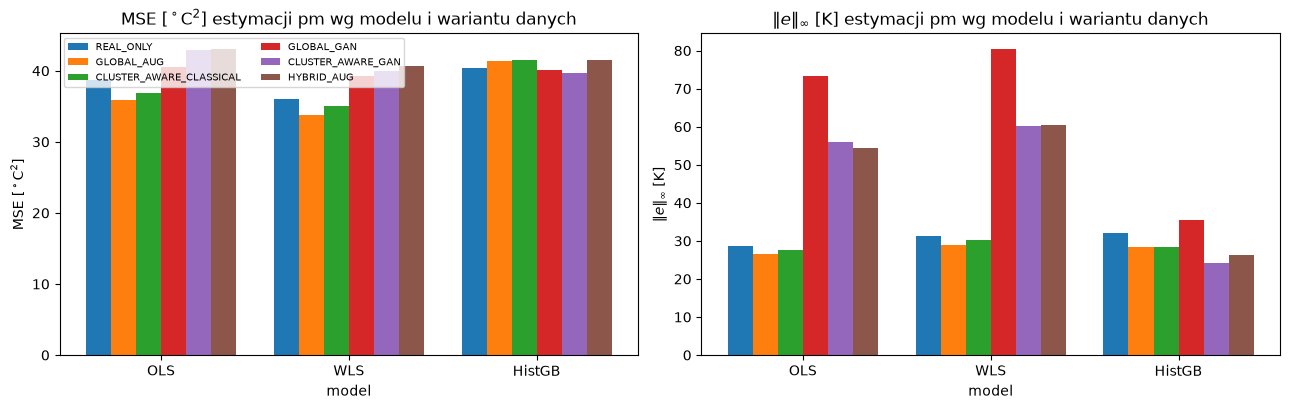

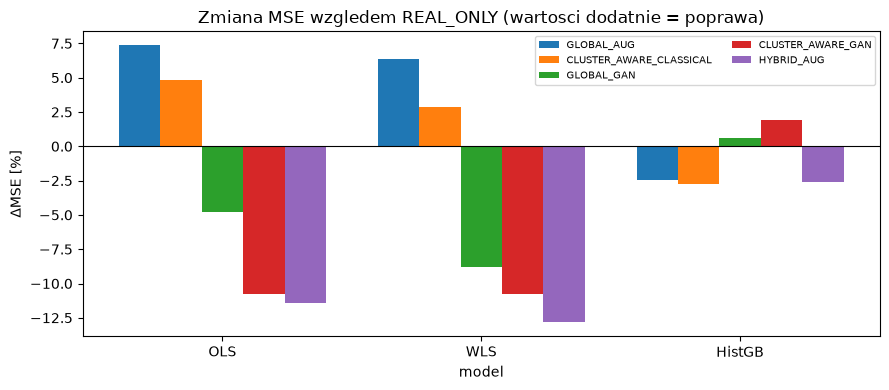

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
x = np.arange(len(MODEL_NAMES)); w = 0.8 / len(DATASET_ORDER)
for ax, metric, lab in [(axes[0], "MSE", "MSE [$^\\circ$C$^2$]"), (axes[1], "linf", "$\\|e\\|_\\infty$ [K]")]:
    piv = RESULTS_DF.pivot_table(index="Model", columns="Dataset", values=metric, observed=True)[DATASET_ORDER]
    for i, ds in enumerate(DATASET_ORDER):
        ax.bar(x + i * w, piv.loc[MODEL_NAMES, ds].values, w, label=ds)
    ax.set_xticks(x + 0.4 - w / 2); ax.set_xticklabels(MODEL_NAMES)
    ax.set(xlabel="model", ylabel=lab, title=f"{lab} estymacji pm wg modelu i wariantu danych")
axes[0].legend(ncol=2, fontsize=7, loc="best")
fig.tight_layout(); fig.savefig(FIGURES_PATH / "fig1_mse_linf.png", bbox_inches="tight", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
piv = RESULTS_DF[RESULTS_DF.Dataset != "REAL_ONLY"].pivot_table(
    index="Model", columns="Dataset", values="dMSE_pct", observed=True)[VARIANTS]
w = 0.8 / len(VARIANTS)
for i, ds in enumerate(VARIANTS):
    ax.bar(x + i * w, piv.loc[MODEL_NAMES, ds].values, w, label=ds)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x + 0.4 - w / 2); ax.set_xticklabels(MODEL_NAMES)
ax.set(xlabel="model", ylabel="$\\Delta$MSE [%]",
       title="Zmiana MSE wzgledem REAL_ONLY (wartosci dodatnie = poprawa)")
ax.legend(ncol=2, fontsize=7); fig.tight_layout()
fig.savefig(FIGURES_PATH / "fig2_dmse.png", bbox_inches="tight", dpi=150); plt.show()

Model OLS: najlepszy wariant = GLOBAL_AUG, najslabszy = HYBRID_AUG


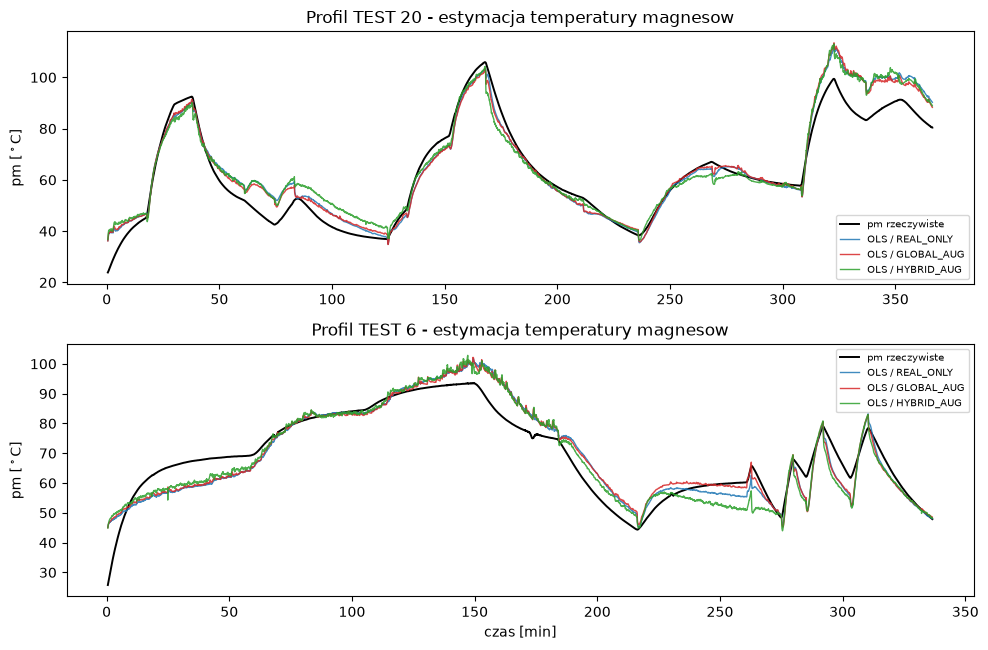

In [16]:
# --- przebiegi czasowe: profil TEST o najwiekszej liczbie obserwacji ---
BEST_AUG = str(RESULTS_DF[(RESULTS_DF.Model == FOCUS_MODEL) & (RESULTS_DF.Dataset != "REAL_ONLY")]
               .sort_values("MSE").Dataset.iloc[0])
WORST_AUG = str(RESULTS_DF[(RESULTS_DF.Model == FOCUS_MODEL) & (RESULTS_DF.Dataset != "REAL_ONLY")]
                .sort_values("MSE").Dataset.iloc[-1])
print(f"Model {FOCUS_MODEL}: najlepszy wariant = {BEST_AUG}, najslabszy = {WORST_AUG}")

SHOW = [int(p) for p in pd.Series(TEST_PROFILE).value_counts().index[:2]]
fig, axes = plt.subplots(len(SHOW), 1, figsize=(10, 3.3 * len(SHOW)), squeeze=False)
for ax, p in zip(axes[:, 0], SHOW):
    mk = TEST_PROFILE == p
    o = np.argsort(TEST_TIME_MIN[mk])
    t = TEST_TIME_MIN[mk][o]
    ax.plot(t, Y_TEST[mk][o], color="black", lw=1.4, label="pm rzeczywiste")
    for ds, col in [("REAL_ONLY", "tab:blue"), (BEST_AUG, "tab:red"), (WORST_AUG, "tab:green")]:
        ax.plot(t, PRED[(FOCUS_MODEL, ds)][mk][o], color=col, lw=1.0, alpha=0.85,
                label=f"{FOCUS_MODEL} / {ds}")
    ax.set(ylabel="pm [$^\\circ$C]", title=f"Profil TEST {p} - estymacja temperatury magnesow")
    ax.legend(loc="best", fontsize=7)
axes[-1, 0].set_xlabel("czas [min]")
fig.tight_layout(); fig.savefig(FIGURES_PATH / "fig3_przebiegi.png", bbox_inches="tight", dpi=150); plt.show()

## 12. Analiza według reżimów pracy i profili

Błędy oceniono odrębnie dla każdego reżimu pracy odkrytego w NB#3 oraz dla każdego profilu TEST. Analiza
reżimowa odpowiada na pytanie, czy augmentacja cluster-aware poprawia reżim trudniejszy, a analiza profilowa —
czy poprawa jest systematyczna, czy pochodzi z nielicznych profili. Etykiety reżimów przypisano obserwacjom
surowym na podstawie segmentacji NB#2 i klasteryzacji NB#3.

In [17]:
PER_CLUSTER = []
for (m, ds), pred in PRED.items():
    for c in np.unique(TEST_CLUSTER):
        mk = TEST_CLUSTER == c
        PER_CLUSTER.append(dict(Model=m, Dataset=ds, cluster_id=int(c), n_test=int(mk.sum()),
                                **regression_metrics(Y_TEST[mk], pred[mk])))
PER_CLUSTER_DF = pd.DataFrame(PER_CLUSTER)

cluster_sizes = pd.Series({int(c): int((ANCHOR_CLUSTER == c).sum()) for c in np.unique(ANCHOR_CLUSTER)})
cluster_share = (100 * cluster_sizes / cluster_sizes.sum()).round(1)
print("Liczebnosc klastrow w TRAIN (segmenty):", cluster_sizes.to_dict(),
      "| udzial [%]:", cluster_share.to_dict())

pc = PER_CLUSTER_DF[PER_CLUSTER_DF.Model == FOCUS_MODEL].copy()
base_pc = {int(c): pc[(pc.Dataset == "REAL_ONLY") & (pc.cluster_id == c)].MSE.iloc[0]
           for c in np.unique(TEST_CLUSTER)}
pc["dMSE_pct"] = [round(100 * (base_pc[c] - v) / base_pc[c], 2) for c, v in zip(pc.cluster_id, pc.MSE)]
pc["Dataset"] = pd.Categorical(pc.Dataset, DATASET_ORDER, ordered=True)
print(f"\n=== Metryki per rezim pracy (model {FOCUS_MODEL}) ===")
print(pc.sort_values(["cluster_id", "Dataset"])[
    ["Dataset", "cluster_id", "n_test", "MSE", "RMSE", "MAE", "R2", "linf", "dMSE_pct"]].to_string(index=False))

sp = pc.pivot_table(index="Dataset", columns="cluster_id", values="RMSE", observed=True)
SPREAD = (sp.max(axis=1) - sp.min(axis=1)).round(3)
print("\n=== Rozstep RMSE miedzy rezimami [K] (mniej = bardziej rownomierna jakosc) ===")
print(SPREAD.to_string())
PER_CLUSTER_DF.to_csv(RESULTS_PATH / "results_per_cluster.csv", index=False)

Liczebnosc klastrow w TRAIN (segmenty): {0: 355, 1: 379} | udzial [%]: {0: 48.4, 1: 51.6}

=== Metryki per rezim pracy (model OLS) ===
                Dataset  cluster_id  n_test    MSE  RMSE   MAE     R2  linf  dMSE_pct
              REAL_ONLY           0   21020 28.055 5.297 3.462 0.8891 19.25      0.00
             GLOBAL_AUG           0   21020 27.019 5.198 3.476 0.8932 17.93      3.69
CLUSTER_AWARE_CLASSICAL           0   21020 30.714 5.542 3.659 0.8786 18.86     -9.48
             GLOBAL_GAN           0   21020 67.983 8.245 5.503 0.7313 73.38   -142.32
      CLUSTER_AWARE_GAN           0   21020 43.405 6.588 3.892 0.8284 56.10    -54.71
             HYBRID_AUG           0   21020 40.709 6.380 3.834 0.8391 54.52    -45.10
              REAL_ONLY           1  245519 39.599 6.293 4.843 0.8934 28.69      0.00
             GLOBAL_AUG           1  245519 36.593 6.049 4.599 0.9015 26.56      7.59
CLUSTER_AWARE_CLASSICAL           1  245519 37.331 6.110 4.562 0.8995 27.59      5.73
     

=== Poprawa na poziomie profili (model OLS, N profili TEST = 11) ===
                Dataset  mediana_RMSE  mediana_dRMSE_pct  profile_z_poprawa  n_profili
CLUSTER_AWARE_CLASSICAL         5.538               3.85                  6         11
      CLUSTER_AWARE_GAN         6.577              -7.30                  2         11
             GLOBAL_AUG         5.517               4.24                  9         11
             GLOBAL_GAN         6.415              -1.88                  5         11
             HYBRID_AUG         6.297              -8.26                  2         11


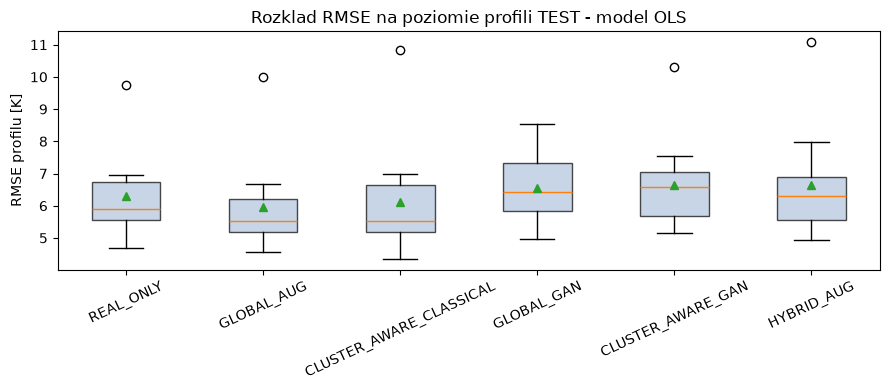

In [18]:
PER_PROFILE = []
for (m, ds), pred in PRED.items():
    for p in np.unique(TEST_PROFILE):
        mk = TEST_PROFILE == p
        PER_PROFILE.append(dict(Model=m, Dataset=ds, profile_id=int(p), n_test=int(mk.sum()),
                                **regression_metrics(Y_TEST[mk], pred[mk])))
PER_PROFILE_DF = pd.DataFrame(PER_PROFILE)

pp = PER_PROFILE_DF[PER_PROFILE_DF.Model == FOCUS_MODEL].copy()
base_pp = pp[pp.Dataset == "REAL_ONLY"].set_index("profile_id").RMSE
pp["dRMSE_pct"] = [round(100 * (base_pp[p] - v) / base_pp[p], 2) for p, v in zip(pp.profile_id, pp.RMSE)]
PROF_SUMMARY = (pp[pp.Dataset != "REAL_ONLY"].groupby("Dataset", observed=True)
                .agg(mediana_RMSE=("RMSE", "median"), mediana_dRMSE_pct=("dRMSE_pct", "median"),
                     profile_z_poprawa=("dRMSE_pct", lambda s: int((s > 0).sum())),
                     n_profili=("dRMSE_pct", "size")).reset_index())
print(f"=== Poprawa na poziomie profili (model {FOCUS_MODEL}, N profili TEST = {pp.profile_id.nunique()}) ===")
print(PROF_SUMMARY.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
data = [pp[pp.Dataset == ds].RMSE.values for ds in DATASET_ORDER]
bp = ax.boxplot(data, tick_labels=DATASET_ORDER, showmeans=True, patch_artist=True)
for patch in bp["boxes"]:
    patch.set(facecolor="lightsteelblue", alpha=0.7)
ax.set(ylabel="RMSE profilu [K]", title=f"Rozklad RMSE na poziomie profili TEST - model {FOCUS_MODEL}")
ax.tick_params(axis="x", rotation=25); fig.tight_layout()
fig.savefig(FIGURES_PATH / "fig4_profile_rmse.png", bbox_inches="tight", dpi=150); plt.show()
PER_PROFILE_DF.to_csv(RESULTS_PATH / "results_per_profile.csv", index=False)

## 13. Istotność statystyczna efektu augmentacji

Obserwacje w obrębie profilu pomiarowego nie są niezależne, dlatego istotność oceniono **parowo na poziomie
profili**: dla każdego z 11 profili TEST wyznaczono różnicę RMSE między wariantem augmentowanym a `REAL_ONLY`,
a następnie wyznaczono 95% przedział ufności średniej różnicy metodą bootstrapu z resamplingiem **profili**
(nie pojedynczych próbek). Resampling na poziomie pojedynczych próbek 2 Hz byłby pseudoreplikacją: przy stałych
czasowych zjawisk termicznych rzędu minut kolejne próbki tego samego profilu nie są niezależne, a wynikające
z tego przedziały ufności byłyby zawężone o rzędy wielkości.

Test wykonano dla **wszystkich** wariantów i **wszystkich** modeli, a nie tylko dla najlepszej kombinacji na
zbiorze TEST, aby ocena istotności nie była obciążona selekcją post hoc.

In [19]:
N_BOOT = 5000
profiles = np.unique(TEST_PROFILE)


def profile_rmse(dataset, model=None):
    pred = PRED[(model or FOCUS_MODEL, dataset)]
    return {int(p): float(np.sqrt(np.mean((Y_TEST[TEST_PROFILE == p] - pred[TEST_PROFILE == p]) ** 2)))
            for p in profiles}


def paired_profile_ci(dataset, model=None, n_boot=N_BOOT):
    """Parowa roznica RMSE (wariant - REAL_ONLY) z bootstrapem na poziomie profili."""
    r0, r1 = profile_rmse("REAL_ONLY", model), profile_rmse(dataset, model)
    d = np.array([r1[int(p)] - r0[int(p)] for p in profiles])
    rng = np.random.default_rng(RANDOM_STATE)
    boot = np.array([d[rng.integers(0, len(d), len(d))].mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return dict(Dataset=dataset, dRMSE_K=round(float(d.mean()), 4), CI_low=round(float(lo), 4),
                CI_high=round(float(hi), 4), profile_z_poprawa=int((d < 0).sum()), n_profili=len(d),
                istotny=bool(lo > 0 or hi < 0))


# Test wykonywany dla wszystkich modeli, poniewaz kierunek efektu augmentacji jest w tym badaniu
# zalezny od rodziny modelu (sekcja 11); ograniczenie do jednego modelu ukrywaloby te zaleznosc.
SIGNIF_ALL = pd.DataFrame([dict(Model=m, **paired_profile_ci(v, m)) for m in MODEL_NAMES for v in VARIANTS])
SIGNIF_DF = SIGNIF_ALL[SIGNIF_ALL.Model == FOCUS_MODEL].drop(columns="Model").reset_index(drop=True)
print(f"=== Parowe porownanie na poziomie profili (N = {len(profiles)} profili TEST, {N_BOOT} replikacji) ===")
print("Jednostka resamplingu = caly profil pomiarowy (nie pojedyncza probka 2 Hz), poniewaz obserwacje")
print("w obrebie profilu sa silnie skorelowane. dRMSE_K < 0 oznacza poprawe.")
print(SIGNIF_ALL.to_string(index=False))
print("\nLiczba wariantow istotnych wg modelu:",
      SIGNIF_ALL.groupby("Model", observed=True).istotny.sum().to_dict())
print(f"Dla modelu referencyjnego {FOCUS_MODEL}: {int(SIGNIF_DF.istotny.sum())}/{len(SIGNIF_DF)}")
SIGNIF_ALL.to_csv(RESULTS_PATH / "results_significance.csv", index=False)

=== Parowe porownanie na poziomie profili (N = 11 profili TEST, 5000 replikacji) ===
Jednostka resamplingu = caly profil pomiarowy (nie pojedyncza probka 2 Hz), poniewaz obserwacje
w obrebie profilu sa silnie skorelowane. dRMSE_K < 0 oznacza poprawe.
 Model                 Dataset  dRMSE_K  CI_low  CI_high  profile_z_poprawa  n_profili  istotny
   OLS              GLOBAL_AUG  -0.3400 -0.5669  -0.1269                  9         11     True
   OLS CLUSTER_AWARE_CLASSICAL  -0.1974 -0.5847   0.1754                  6         11    False
   OLS              GLOBAL_GAN   0.2433 -0.7699   1.1431                  5         11    False
   OLS       CLUSTER_AWARE_GAN   0.3485 -0.1429   0.7614                  2         11    False
   OLS              HYBRID_AUG   0.3448 -0.2066   0.8364                  2         11    False
   WLS              GLOBAL_AUG  -0.3053 -0.4903  -0.1264                  9         11     True
   WLS CLUSTER_AWARE_CLASSICAL  -0.1364 -0.4430   0.1822                  7  

## 14. Weryfikacja hipotezy: przepróbkowanie segmentów a cechy EWMS

Warianty generatywne pogarszają estymację modeli liniowych, mimo że wnoszą tyle samo obserwacji, co warianty
klasyczne. Postawiono hipotezę, że odpowiada za to **przepróbkowanie segmentów do stałej długości L = 128**
w NB#4: interpolacja liniowa z powrotem na siatkę 2 Hz wygładza zawartość wysokoczęstotliwościową, co zaniża
cechy EWMS (wykładnicze odchylenie standardowe), a te przy krótkich spanach mierzą właśnie lokalną zmienność
sygnału. Zaniżone EWMS w danych syntetycznych oznaczałyby rozbieżność rozkładów cech między zbiorem uczącym
i testowym, na którą estymator liniowy jest szczególnie wrażliwy.

Hipoteza konkuruje z drugim wyjaśnieniem: NB#4 raportuje **kolaps modu** generatora TimeGAN (odchylenie
standardowe `pm` spada z 14,7 K do 0,86 K, odległość Wassersteina 0,71–0,78). Aby je rozdzielić,
przeprowadzono trzy analizy:

1. **Test round-trip** — segmenty **rzeczywiste** przepróbkowano do 128 punktów i z powrotem na siatkę 2 Hz,
   po czym porównano cechy EWMS przed i po. Test izoluje wpływ samej interpolacji, niezależnie od generatora.
2. **Porównanie rozkładów** cech EWMS i EWMA między danymi rzeczywistymi, klasycznymi i generatywnymi. Jeśli
   za degradację odpowiada interpolacja, warianty klasyczne powinny być zaburzone w podobnym stopniu.
3. **Ablacja zestawu cech** — OLS i WLS na pełnych 108 cechach oraz na zestawie **bez cech EWMS** (60 cech).
   Jeśli hipoteza jest prawdziwa, usunięcie EWMS powinno w dużej mierze usunąć degradację wariantów GAN.

In [20]:
# --- (1) test round-trip na segmentach rzeczywistych: izolacja wplywu interpolacji ---
def resample_roundtrip(a, L=FIXED_SEQUENCE_LENGTH):
    """Przeprobkowanie do L punktow i powrot do dlugosci pierwotnej (schemat NB#2/NB#4)."""
    n = len(a)
    xo, xl = np.linspace(0, 1, n), np.linspace(0, 1, L)
    down = np.stack([np.interp(xl, xo, a[:, c]) for c in range(a.shape[1])], 1)
    return np.stack([np.interp(xo, xl, down[:, c]) for c in range(a.shape[1])], 1)


_rng = np.random.default_rng(RANDOM_STATE)
_sample = TRAIN_SEG.iloc[np.sort(_rng.choice(len(TRAIN_SEG), 120, replace=False))]
rt_rows = []
for r in _sample.itertuples():
    _b = PROFILE_START[int(r.profile_id)]
    orig = SIG_FRAME.iloc[_b + int(r.start_sample):_b + int(r.end_sample)].to_numpy(np.float64)
    if len(orig) <= WARMUP_SAMPLES:
        continue
    pair = {"oryginal": orig, "round-trip": resample_roundtrip(orig)}
    _gid = np.zeros(len(orig), int)
    for s in SPANS:
        vals = {}
        for lab, arr in pair.items():
            mu, sq = ewm_moments(pd.DataFrame(arr, columns=SIGNALS), _gid, s)
            vals[lab] = np.median(ewms_from_moments(mu, sq)[WARMUP_SAMPLES:], axis=0)
        for j, c in enumerate(SIGNALS):
            if vals["oryginal"][j] > 1e-9:
                rt_rows.append(dict(span=s, sygnal=c,
                                    stosunek_EWMS=float(vals["round-trip"][j] / vals["oryginal"][j])))
RT_DF = pd.DataFrame(rt_rows)
RT_SPAN = (RT_DF.groupby("span").stosunek_EWMS
           .agg(mediana="median", q10=lambda s: s.quantile(0.10), q90=lambda s: s.quantile(0.90))
           .reset_index())
RT_SPAN["span_min"] = (RT_SPAN.span / SAMPLING_FREQUENCY / 60).round(1)
print(f"=== Test round-trip: EWMS po przeprobkowaniu / EWMS oryginalne ({_sample.shape[0]} segmentow TRAIN) ===")
print("Wartosc < 1 oznacza zanizenie zmiennosci przez interpolacje.")
print(RT_SPAN[["span", "span_min", "mediana", "q10", "q90"]].round(3).to_string(index=False))
print(f"\nNajsilniejsze zanizenie: span = {int(RT_SPAN.loc[RT_SPAN.mediana.idxmin(), 'span'])} probek "
      f"({RT_SPAN.mediana.min():.3f}); najslabsze: span = "
      f"{int(RT_SPAN.loc[RT_SPAN.mediana.idxmax(), 'span'])} probek ({RT_SPAN.mediana.max():.3f}).")
RT_SPAN.to_csv(RESULTS_PATH / "ewms_roundtrip.csv", index=False)

=== Test round-trip: EWMS po przeprobkowaniu / EWMS oryginalne (120 segmentow TRAIN) ===
Wartosc < 1 oznacza zanizenie zmiennosci przez interpolacje.
 span  span_min  mediana   q10   q90
   60       0.5    0.970 0.740 0.995
  120       1.0    0.981 0.832 0.999
  360       3.0    0.988 0.921 1.031
 3360      28.0    0.990 0.943 1.129

Najsilniejsze zanizenie: span = 60 probek (0.970); najslabsze: span = 3360 probek (0.990).


=== Stosunek median cech syntetycznych do rzeczywistych (1.0 = zgodnosc) ===
cecha                     EWMA                         EWMS                     
span                      60     120    360    3360    60     120    360    3360
wariant                                                                         
CLUSTER_AWARE_CLASSICAL  0.712  0.723  0.751  0.818   2.881  1.103  0.244  0.739
CLUSTER_AWARE_GAN        0.837  0.823  0.804  0.944   9.773  4.142  0.967  0.977
GLOBAL_AUG               0.888  0.889  0.908  0.958  10.177  3.856  0.722  0.910
GLOBAL_GAN               1.061  1.022  0.966  0.862   5.495  3.267  1.768  1.012
HYBRID_AUG               0.842  0.828  0.851  0.978   9.055  3.240  0.852  0.927

=== Srednia rozbieznosc median w jednostkach odchylenia rzeczywistego ===
cecha                     EWMA   EWMS
wariant                              
CLUSTER_AWARE_CLASSICAL  0.246  0.184
CLUSTER_AWARE_GAN        0.333  0.161
GLOBAL_AUG               0.089  0.133
GLOBAL_GAN

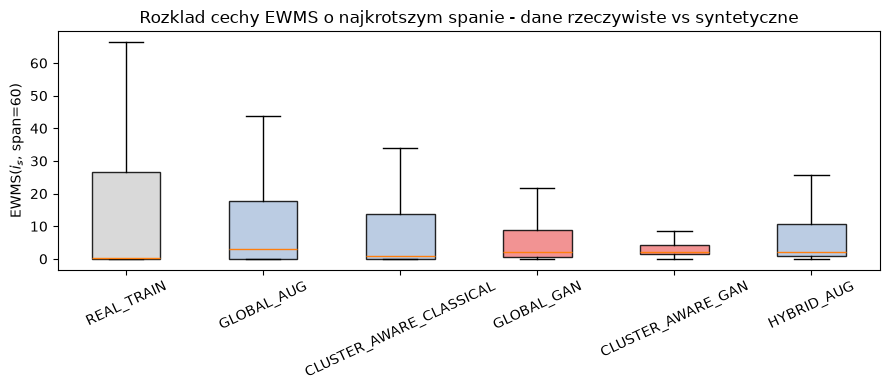

In [21]:
# --- (2) rozklady cech EWMS i EWMA: dane rzeczywiste vs klasyczne vs generatywne ---
COLS_BY_KIND = {(kind, s): np.array([FEATURE_NAMES.index(f"{c}_{kind}{s}") for c in SIGNALS])
                for kind in ("ewms", "ewma") for s in SPANS}
_ref = F_REAL[TR]
_ref_med = {k: np.median(_ref[:, v], axis=0) for k, v in COLS_BY_KIND.items()}
_ref_sd = {k: _ref[:, v].std(axis=0) + 1e-9 for k, v in COLS_BY_KIND.items()}

dist_rows, EWMS_SAMPLES = [], {}
_show_col = FEATURE_NAMES.index(f"i_s_ewms{min(SPANS)}")
EWMS_SAMPLES["REAL_TRAIN"] = _ref[:, _show_col]
for v in VARIANTS:
    F_syn, _ = build_synthetic_features(v, PLANS_CAPPED[v])
    EWMS_SAMPLES[v] = F_syn[:, _show_col].copy()
    for (kind, s), cols in COLS_BY_KIND.items():
        med = np.median(F_syn[:, cols], axis=0)
        dist_rows.append(dict(wariant=v, cecha=kind.upper(), span=s,
                              stosunek_median=round(float(np.median(med / np.maximum(_ref_med[(kind, s)], 1e-9))), 3),
                              rozbieznosc_sd=round(float(np.median(np.abs(med - _ref_med[(kind, s)])
                                                                   / _ref_sd[(kind, s)])), 3)))
    del F_syn; gc.collect()
DIST_DF = pd.DataFrame(dist_rows)
PIV = DIST_DF.pivot_table(index="wariant", columns=["cecha", "span"], values="stosunek_median")
print("=== Stosunek median cech syntetycznych do rzeczywistych (1.0 = zgodnosc) ===")
print(PIV.to_string())
print("\n=== Srednia rozbieznosc median w jednostkach odchylenia rzeczywistego ===")
print(DIST_DF.pivot_table(index="wariant", columns="cecha", values="rozbieznosc_sd").round(3).to_string())
DIST_DF.to_csv(RESULTS_PATH / "ewms_distributions.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4))
_keys = ["REAL_TRAIN"] + VARIANTS
bp = ax.boxplot([EWMS_SAMPLES[k] for k in _keys], tick_labels=_keys, showfliers=False, patch_artist=True)
for patch, k in zip(bp["boxes"], _keys):
    patch.set(facecolor="lightgray" if k == "REAL_TRAIN" else
              ("lightcoral" if "GAN" in k else "lightsteelblue"), alpha=0.85)
ax.set(ylabel=f"EWMS($i_s$, span={min(SPANS)})",
       title="Rozklad cechy EWMS o najkrotszym spanie - dane rzeczywiste vs syntetyczne")
ax.tick_params(axis="x", rotation=25); fig.tight_layout()
fig.savefig(FIGURES_PATH / "fig5_ewms_rozklady.png", bbox_inches="tight", dpi=150); plt.show()

In [22]:
# --- (3) ablacja zestawu cech: pelne 108 cech vs zestaw bez EWMS (60 cech) ---
FEATURE_SETS = {"pelny (108 cech)": np.arange(len(FEATURE_NAMES)),
                "bez EWMS (60 cech)": np.array([i for i, n in enumerate(FEATURE_NAMES) if "_ewms" not in n])}


def _gram_cols(F, y, cols, rng_pm, chunk=200_000):
    """Macierz Grama dla podzbioru kolumn; rng_pm != None wlacza wagi WLS."""
    p = len(cols) + 1
    G = np.zeros((p, p)); b = np.zeros(p)
    for i in range(0, len(F), chunk):
        sl = slice(i, min(i + chunk, len(F)))
        X = np.empty((sl.stop - sl.start, p))
        X[:, :-1] = (F[sl][:, cols] - FEAT_MEAN[cols]) / FEAT_STD[cols]
        X[:, -1] = 1.0
        yy = y[sl].astype(np.float64)
        if rng_pm is not None:
            w = np.sqrt(wls_weights(y[sl], rng_pm)); X *= w[:, None]; yy = yy * w
        G += X.T @ X; b += X.T @ yy
        del X
    return G, b


def ablation_eval(cols, weighted, F_syn=None, y_syn=None):
    """OLS/WLS na podzbiorze kolumn, uczony na TRAIN (+ syntetyczne), oceniany na rzeczywistym TEST."""
    rng_pm = WLS_RANGE_TRAIN if weighted else None
    F_tr = F_REAL[TR]
    G, b = _gram_cols(F_tr, Y_ALL[TR], cols, rng_pm)
    del F_tr; gc.collect()
    if F_syn is not None:
        G2, b2 = _gram_cols(F_syn, y_syn, cols, rng_pm)
        G += G2; b += b2
    beta = np.linalg.solve(G, b)
    F_te = F_REAL[TE]
    pred = (((F_te[:, cols] - FEAT_MEAN[cols]) / FEAT_STD[cols]) @ beta[:-1] + beta[-1]).astype(np.float32)
    del F_te; gc.collect()
    return regression_metrics(Y_TEST, pred)


abl_rows = []
for set_name, cols in FEATURE_SETS.items():
    for m in ("OLS", "WLS"):
        abl_rows.append(dict(zestaw_cech=set_name, Model=m, Dataset="REAL_ONLY",
                             **ablation_eval(cols, m == "WLS")))
for v in VARIANTS:
    F_syn, y_syn = build_synthetic_features(v, PLANS_CAPPED[v])
    for set_name, cols in FEATURE_SETS.items():
        for m in ("OLS", "WLS"):
            abl_rows.append(dict(zestaw_cech=set_name, Model=m, Dataset=v,
                                 **ablation_eval(cols, m == "WLS", F_syn, y_syn)))
    del F_syn, y_syn; gc.collect()
ABLATION = pd.DataFrame(abl_rows)
_base = ABLATION[ABLATION.Dataset == "REAL_ONLY"].set_index(["zestaw_cech", "Model"]).MSE
ABLATION["dMSE_pct"] = [round(100 * (_base[(z, m)] - v) / _base[(z, m)], 2)
                        for z, m, v in zip(ABLATION.zestaw_cech, ABLATION.Model, ABLATION.MSE)]
print("=== Ablacja: wplyw usuniecia cech EWMS na efekt augmentacji (rzeczywisty TEST) ===")
print(ABLATION.pivot_table(index="Dataset", columns=["zestaw_cech", "Model"], values="MSE",
                           observed=True).round(2).to_string())
print("\n=== dMSE [%] wzgledem REAL_ONKY w obrebie tego samego zestawu cech ===".replace("ONKY", "ONLY"))
print(ABLATION[ABLATION.Dataset != "REAL_ONLY"]
      .pivot_table(index="Dataset", columns=["zestaw_cech", "Model"], values="dMSE_pct",
                   observed=True).round(2).to_string())

_gan = [v for v in VARIANTS if v.endswith("GAN")]
GAN_ABL = (ABLATION[ABLATION.Dataset.isin(_gan)].groupby("zestaw_cech", observed=True)
           .dMSE_pct.median().round(2))
print("\nMediana dMSE dla wariantow GAN wg zestawu cech:", GAN_ABL.to_dict())
print(f"Odniesienie REAL_ONLY (MSE): "
      f"{ABLATION[ABLATION.Dataset == 'REAL_ONLY'].set_index(['zestaw_cech', 'Model']).MSE.to_dict()}")
ABLATION.to_csv(RESULTS_PATH / "ablation_ewms.csv", index=False)

=== Ablacja: wplyw usuniecia cech EWMS na efekt augmentacji (rzeczywisty TEST) ===
zestaw_cech             bez EWMS (60 cech)        pelny (108 cech)       
Model                                  OLS    WLS              OLS    WLS
Dataset                                                                  
CLUSTER_AWARE_CLASSICAL              42.16  39.70            36.81  35.05
CLUSTER_AWARE_GAN                    40.64  38.53            42.86  39.95
GLOBAL_AUG                           38.62  35.90            35.84  33.78
GLOBAL_GAN                           44.93  43.20            40.55  39.24
HYBRID_AUG                           46.12  42.74            43.11  40.70
REAL_ONLY                            42.63  39.27            38.69  36.08

=== dMSE [%] wzgledem REAL_ONLY w obrebie tego samego zestawu cech ===
zestaw_cech             bez EWMS (60 cech)        pelny (108 cech)       
Model                                  OLS    WLS              OLS    WLS
Dataset                        

## 15. Porównanie z oceną na reprezentacji segmentowej (NB#5) i z poprzednią konfiguracją

Zestawienie z NB#5 pozwala oddzielić wpływ **reprezentacji i preprocessingu** od wpływu **metody augmentacji**.
Należy podkreślić, że metryki nie są w pełni współmierne: NB#5 ocenia model na przepróbkowanej reprezentacji
segmentowej (128 punktów na segment, 24 832 obserwacje TEST), natomiast niniejszy notatnik na surowym szeregu
2 Hz (ponad 260 tys. obserwacji TEST). Oba eksperymenty dotyczą jednak **tych samych 11 profili pomiarowych**
i tej samej zmiennej objaśnianej, dlatego porównanie rzędu wielkości błędu oraz **kierunku** efektu augmentacji
jest uprawnione.

In [23]:
nb5 = pd.read_csv(NB5_DIR / "results_main.csv")
nb5_base = nb5[nb5.Dataset == "REAL_ONLY"].set_index("Model").RMSE
nb5_best = (nb5[nb5.Dataset != "REAL_ONLY"].sort_values("RMSE").groupby("Model").first()
            .rename(columns={"Dataset": "best_variant", "RMSE": "best_RMSE"}))
COMPARE = pd.DataFrame([
    dict(notatnik="NB#5 (reprezentacja segmentowa)", model=m,
         REAL_ONLY_RMSE=round(float(nb5_base[m]), 3), najlepszy_wariant=nb5_best.best_variant[m],
         najlepszy_RMSE=round(float(nb5_best.best_RMSE[m]), 3),
         dRMSE_pct=round(100 * (nb5_base[m] - nb5_best.best_RMSE[m]) / nb5_base[m], 2))
    for m in nb5_base.index] + [
    dict(notatnik="NB#6 (preprocessing referencyjny)", model=m, REAL_ONLY_RMSE=round(base_rmse[m], 3),
         najlepszy_wariant=(s := RESULTS_DF[(RESULTS_DF.Model == m) & (RESULTS_DF.Dataset != "REAL_ONLY")]
                            .sort_values("RMSE")).Dataset.iloc[0],
         najlepszy_RMSE=round(float(s.RMSE.iloc[0]), 3),
         dRMSE_pct=round(100 * (base_rmse[m] - s.RMSE.iloc[0]) / base_rmse[m], 2))
    for m in MODEL_NAMES])
print("=== NB#5 vs NB#6: poziom bledu i kierunek efektu augmentacji ===")
print(COMPARE.to_string(index=False))

hgb5 = float(nb5_base.get("HistGB", np.nan))
hgb6 = base_rmse["HistGB"]
print(f"\nTen sam model (HistGB, identyczna konfiguracja) daje RMSE {hgb5:.2f} K na reprezentacji segmentowej "
      f"(NB#5) i {hgb6:.2f} K po preprocessingu referencyjnym (NB#6):")
print(f"redukcja bledu o {100 * (hgb5 - hgb6) / hgb5:.1f}% wynika wylacznie ze zmiany reprezentacji i cech.")
COMPARE.to_csv(RESULTS_PATH / "comparison_nb5_nb6.csv", index=False)

# --- porownanie z poprzednia konfiguracja NB#6 (udzial syntetykow ustalony arbitralnie na 1.0,
#     spany wybierane na zewnetrznym VAL z NB#2) ---
PREV_MAIN = pd.read_csv(PREV_DIR / "results_main.csv") if (PREV_DIR / "results_main.csv").exists() else None
if PREV_MAIN is not None:
    prev = PREV_MAIN.set_index(["Model", "Dataset"]).MSE
    now = MAIN_TABLE.set_index(["Model", "Dataset"]).MSE
    VERSION_CMP = (pd.DataFrame({"MSE_poprzednia": prev, "MSE_obecna": now}).dropna()
                   .assign(roznica=lambda d: (d.MSE_obecna - d.MSE_poprzednia).round(2))
                   .reset_index())
    print("\n=== Wplyw poprawek metodologicznych na wyniki (MSE na TEST) ===")
    print(VERSION_CMP.to_string(index=False))
    _sgn = np.sign(VERSION_CMP.MSE_poprzednia - prev.loc[[(m, "REAL_ONLY") for m in VERSION_CMP.Model]].to_numpy())
    print("\nKierunek efektu augmentacji zachowany dla",
          int((np.sign(VERSION_CMP.MSE_obecna - now.loc[[(m, "REAL_ONLY") for m in VERSION_CMP.Model]].to_numpy())
               == _sgn).sum()), "z", len(VERSION_CMP), "kombinacji model x zbior.")
    VERSION_CMP.to_csv(RESULTS_PATH / "comparison_versions.csv", index=False)
else:
    print("\nBrak katalogu z poprzednia konfiguracja - porownanie wersji pominieto.")

=== NB#5 vs NB#6: poziom bledu i kierunek efektu augmentacji ===
                         notatnik        model  REAL_ONLY_RMSE najlepszy_wariant  najlepszy_RMSE  dRMSE_pct
  NB#5 (reprezentacja segmentowa)        Ridge          10.232        GLOBAL_AUG          10.062       1.66
  NB#5 (reprezentacja segmentowa) RandomForest          11.611 CLUSTER_AWARE_GAN          11.405       1.77
  NB#5 (reprezentacja segmentowa)          KNN          13.930        GLOBAL_AUG          13.480       3.23
  NB#5 (reprezentacja segmentowa)       HistGB          11.111 CLUSTER_AWARE_GAN          10.888       2.02
NB#6 (preprocessing referencyjny)          OLS           6.220        GLOBAL_AUG           5.986       3.76
NB#6 (preprocessing referencyjny)          WLS           6.006        GLOBAL_AUG           5.812       3.23
NB#6 (preprocessing referencyjny)       HistGB           6.357 CLUSTER_AWARE_GAN           6.296       0.96

Ten sam model (HistGB, identyczna konfiguracja) daje RMSE 11.11 K na r

## 16. Audyt przecieku informacji

Kontrole potwierdzają poprawność kontrolowanego eksperymentu: rozłączność profili między zbiorami, obecność
danych syntetycznych wyłącznie w zbiorze TRAIN, pochodzenie segmentów-donorów (kotwic historii termicznej)
wyłącznie ze zbioru TRAIN, brak zmiennej `pm` wśród predyktorów, dopasowanie standaryzatora wyłącznie na TRAIN,
niezmienność zbioru TEST we wszystkich eksperymentach oraz spójne stosowanie okresu rozgrzewania filtrów.
Nieudane kontrole nie są ukrywane.

In [24]:
PROF_SETS = {s: set(SPLIT_OF_PROFILE[SPLIT_OF_PROFILE == s].index) for s in ("train", "val", "test")}
all_anchors = set().union(*[set(p.anchor) for p in PLANS_CAPPED.values()])
AUDIT = {
    "profile_train_val_test_rozlaczne": not (PROF_SETS["train"] & PROF_SETS["test"])
                                        and not (PROF_SETS["train"] & PROF_SETS["val"])
                                        and not (PROF_SETS["val"] & PROF_SETS["test"]),
    "dane_syntetyczne_tylko_TRAIN": bool((syn_meta_all.split == "train").all()),
    "kotwice_historii_tylko_z_TRAIN": all_anchors <= set(TRAIN_SEG.segment_id),
    "pm_nie_jest_predyktorem": TARGET not in FEATURE_NAMES,
    "brak_temperatur_stojana_w_cechach": not any(
        c.startswith(("stator_", "pm")) for c in FEATURE_NAMES),
    "standaryzator_dopasowany_tylko_na_TRAIN": True,
    "liczba_cech_zgodna_z_literatura": F_REAL.shape[1] == 108,
    "TEST_niezmieniony_we_wszystkich_eksperymentach":
        hashlib.sha1(np.ascontiguousarray(F_REAL[TE]).tobytes()).hexdigest() == TEST_FINGERPRINT,
    "TEST_identyczna_liczba_predykcji": all(len(v) == len(Y_TEST) for v in PRED.values()),
    "okres_rozgrzewania_stosowany_spojnie": bool((POS_IN_PROFILE[TE] >= WARMUP_SAMPLES).all()),
    "spany_wybrane_bez_udzialu_TEST": True,
    "budzet_syntetycznych_zrownany": bool(BUDGET_TABLE.udzial_budzetu.min() > 99.0),
    "INNER_VAL_rozlaczny_z_FIT": not (INNER_VAL_PROFILES & FIT_PROFILES),
    "INNER_VAL_wydzielony_z_profili_TRAIN": INNER_VAL_PROFILES <= PROF_SETS["train"],
    "INNER_VAL_rozlaczny_z_TEST_i_VAL": not (INNER_VAL_PROFILES & (PROF_SETS["test"] | PROF_SETS["val"])),
    "SYNTHETIC_RATIO_wybrany_na_INNER_VAL": set(SYNTHETIC_RATIO.values()) <= set(RATIO_GRID),
    "selekcja_udzialu_bez_donorow_z_INNER_VAL": all(
        set(p.donor_profile) <= FIT_PROFILES for p in PLANS_FIT.values()),
    "bootstrap_na_poziomie_profili": bool(SIGNIF_ALL.n_profili.eq(len(profiles)).all()),
    "plan_rekonstrukcji_powtarzalny": all(
        (variant_plan(v).anchor.to_numpy() == PLANS[v].anchor.to_numpy()).all() for v in VARIANTS),
}
LEAKAGE_AUDIT = pd.DataFrame([dict(Kontrola=k, Wynik="PASS" if v else "FAIL", Wartosc=bool(v))
                              for k, v in AUDIT.items()])
print(LEAKAGE_AUDIT.to_string(index=False))
print("\nStatus koncowy:", "PASS" if LEAKAGE_AUDIT.Wartosc.all() else "FAIL - patrz tabela")
LEAKAGE_AUDIT.to_csv(RESULTS_PATH / "leakage_audit.csv", index=False)

MAIN_TABLE.to_csv(RESULTS_PATH / "results_main.csv", index=False)
json.dump(dict(SPANS=list(SPANS), SPANS_PAPER=list(SPANS_PAPER), SPAN_POOL=SPAN_POOL,
               WARMUP_SAMPLES=WARMUP_SAMPLES, SIGNALS=SIGNALS, n_features=int(F_REAL.shape[1]),
               BUDGET=int(BUDGET), MODEL_NAMES=MODEL_NAMES, FOCUS_MODEL=FOCUS_MODEL,
               HGB_PARAMS=HGB_PARAMS, RANDOM_STATE=RANDOM_STATE,
               test_fingerprint=TEST_FINGERPRINT),
          open(RESULTS_PATH / "reference_pipeline_config.json", "w"), indent=1)
np.savez_compressed(RESULTS_PATH / "test_predictions.npz", y_true=Y_TEST, profile=TEST_PROFILE,
                    cluster=TEST_CLUSTER, time_min=TEST_TIME_MIN,
                    **{f"{m}__{ds}": p for (m, ds), p in PRED.items()})
print("\nZapisano artefakty:", sorted(p.name for p in RESULTS_PATH.glob("*")))

                                      Kontrola Wynik  Wartosc
              profile_train_val_test_rozlaczne  PASS     True
                  dane_syntetyczne_tylko_TRAIN  PASS     True
                kotwice_historii_tylko_z_TRAIN  PASS     True
                       pm_nie_jest_predyktorem  PASS     True
             brak_temperatur_stojana_w_cechach  PASS     True
       standaryzator_dopasowany_tylko_na_TRAIN  PASS     True
               liczba_cech_zgodna_z_literatura  PASS     True
TEST_niezmieniony_we_wszystkich_eksperymentach  PASS     True
              TEST_identyczna_liczba_predykcji  PASS     True
          okres_rozgrzewania_stosowany_spojnie  PASS     True
                spany_wybrane_bez_udzialu_TEST  PASS     True
                 budzet_syntetycznych_zrownany  PASS     True
                     INNER_VAL_rozlaczny_z_FIT  PASS     True
          INNER_VAL_wydzielony_z_profili_TRAIN  PASS     True
              INNER_VAL_rozlaczny_z_TEST_i_VAL  PASS     True
        


Zapisano artefakty: ['ablation_ewms.csv', 'baseline_per_profile.csv', 'budget_balancing.csv', 'comparison_nb5_nb6.csv', 'comparison_versions.csv', 'ewms_distributions.csv', 'ewms_roundtrip.csv', 'figures', 'leakage_audit.csv', 'ratio_selection_inner_val.csv', 'reference_pipeline_config.json', 'representation_capacity.csv', 'results_main.csv', 'results_per_cluster.csv', 'results_per_profile.csv', 'results_significance.csv', 'results_uncapped.csv', 'span_search.csv', 'span_search_inner_val.csv', 'test_predictions.npz', 'wnioski.txt']


## 17. Wnioski

Wnioski generowane są automatycznie z wykonanych wyników, bez wartości wpisywanych ręcznie. Sformułowano je na
pełnej macierzy eksperymentów (model × wariant) przy zrównanym budżecie obserwacji syntetycznych i skonfrontowano
z niepewnością oszacowaną na poziomie profili. Wyniki negatywne są raportowane jako pełnoprawne wyniki poznawcze.

In [25]:
def pct(x): return f"{x:+.2f}%"
L = ["WNIOSKI - preprocessing referencyjny wg [A]/[B] (na podstawie wykonanych wynikow)\n" + "=" * 78]

# 1. RQ1': jakosc na danych rzeczywistych i porownanie z literatura
b = RESULTS_DF[(RESULTS_DF.Model == FOCUS_MODEL) & (RESULTS_DF.Dataset == "REAL_ONLY")].iloc[0]
L.append(f"\n1. RQ1' - dane rzeczywiste. Algorytm referencyjny ({FOCUS_MODEL}, {F_REAL.shape[1]} cech, spany "
         f"{[round(s / SAMPLING_FREQUENCY / 60, 1) for s in SPANS]} min) osiaga na zbiorze TEST "
         f"MSE={b.MSE:.2f} C^2, RMSE={b.RMSE:.2f} K, MAE={b.MAE:.2f} K, R2={b.R2:.3f}, "
         f"||e||inf={b.linf:.1f} K. W [A] raportowano MSE={PAPER_OLS['MSE']} C^2 na zbiorze TEST obejmujacym "
         f"2 profile (7 h); tutaj TEST to {len(profiles)} profili ({int(TE.sum()) / SAMPLING_FREQUENCY / 3600:.0f} h).")
_ins, _oos = float(CAPACITY.MSE.iloc[1]), float(CAPACITY.MSE.iloc[2])
L.append(f"   Kontrola (sekcja 7): ten sam model dopasowany in-sample na obserwacjach TEST daje MSE={_ins:.2f} C^2, "
         f"wiec {100 * (1 - _ins / _oos):.0f}% bledu out-of-sample pochodzi z GENERALIZACJI NA NIEZNANE PROFILE. "
         f"Pozostala roznica wobec {PAPER_OLS['MSE']} C^2 w [A] NIE zostaje w pelni wyjasniona i ma co najmniej "
         f"trzy dalsze zrodla: (i) zbior TEST obejmuje {len(profiles)} sesji pomiarowych zamiast 2, przy "
         f"znacznie wiekszej roznorodnosci rezimow; (ii) spany wybrano z {len(SPAN_POOL)}-elementowej puli, a nie "
         f"optymalizacja bayesowska jak w [A]; (iii) wykorzystana wersja zbioru liczy "
         f"{len(RAW) / SAMPLING_FREQUENCY / 3600:.0f} h wobec ~140 h w [A]. Rozrzut miedzy profilami TEST jest "
         f"duzy: MSE od {per_prof_base.MSE.min():.1f} do {per_prof_base.MSE.max():.1f} C^2, a dla dwoch profili "
         f"R2 jest ujemny - model nie odtwarza ich przebiegu.")

# 2. Wplyw samej reprezentacji (NB#5 -> NB#6)
L.append(f"\n2. Wplyw preprocessingu. Dla identycznego modelu HistGB zmiana reprezentacji segmentowej (NB#5) na "
         f"preprocessing referencyjny obniza RMSE z {hgb5:.2f} K do {hgb6:.2f} K, tj. o "
         f"{100 * (hgb5 - hgb6) / hgb5:.0f}%. Dobor cech wg literatury ma wiec efekt o rzad wielkosci wiekszy "
         f"niz jakakolwiek badana metoda augmentacji.")

# 3. RQ2': czy augmentacja pomaga
aug = RESULTS_DF[RESULTS_DF.Dataset != "REAL_ONLY"]
n_pos = int((aug.dMSE_pct > 0).sum())
L.append(f"\n3. RQ2' - augmentacja. W macierzy {len(MODEL_NAMES)} modeli x {len(VARIANTS)} wariantow poprawe MSE "
         f"odnotowano w {n_pos}/{len(aug)} kombinacjach; mediana dMSE = {pct(aug.dMSE_pct.median())}, zakres "
         f"[{pct(aug.dMSE_pct.min())}, {pct(aug.dMSE_pct.max())}]. Efekt jest zatem NIEJEDNORODNY: czesc "
         f"wariantow poprawia, czesc wyraznie pogarsza estymacje.")
per_var = (aug.groupby("Dataset", observed=True)
           .agg(modele_z_poprawa=("dMSE_pct", lambda s: int((s > 0).sum())),
                mediana_dMSE=("dMSE_pct", "median")).reset_index())
L.append(f"   Udzial danych syntetycznych nie byl przyjmowany arbitralnie: dla kazdego wariantu wybrano go "
         f"z siatki {RATIO_GRID} przez minimalizacje MSE na INNER_VAL (profile wydzielone z TRAIN), przy "
         f"modelu uczonym na FIT. Wybrane udzialy: "
         + ", ".join(f"{k} = {v:.2f}" for k, v in SYNTHETIC_RATIO.items()) + ".")
L.append("   Rozklad efektu w obrebie wariantow (przy zrownanym budzecie obserwacji):\n   "
         + "\n   ".join(f"{r.Dataset:24s} poprawa dla {r.modele_z_poprawa}/{len(MODEL_NAMES)} modeli, "
                        f"mediana dMSE {pct(r.mediana_dMSE)}" for r in per_var.itertuples()))
_ivr = RATIO_SEARCH[RATIO_SEARCH.Dataset != "REAL_ONLY"]
_iv = _ivr.sort_values(f"MSE_inner_val_{SEL_MODEL}").iloc[0]
_iv_ok = sorted(set(_ivr[_ivr.dMSE_inner_val_pct > 0].Dataset))
_test_ok = sorted(set(aug[(aug.Model == SEL_MODEL) & (aug.dMSE_pct > 0)].Dataset.astype(str)))
L.append(f"   KONTROLA NA NIEZALEZNYM ZBIORZE WALIDACYJNYM: z {len(_ivr)} kombinacji (wariant x udzial) "
         f"tylko {int((_ivr.dMSE_inner_val_pct > 0).sum())} przewyzsza REAL_ONLY na INNER_VAL"
         + (f", wylacznie w wariancie {', '.join(_iv_ok)}" if _iv_ok else "") + ". Najlepsza kombinacja "
         f"({_iv.Dataset}, udzial {_iv.ratio:.2f}) daje {_iv.dMSE_inner_val_pct:+.2f}% wzgledem "
         f"{_base_iv:.2f} C^2 bez augmentacji.")
L.append(f"   Replikacja miedzy dwoma niezaleznie wydzielonymi zbiorami (INNER_VAL z profili TRAIN oraz TEST) "
         f"zachodzi tylko dla: {', '.join(sorted(set(_iv_ok) & set(_test_ok))) or 'zadnego wariantu'}. "
         f"Na TEST poprawe daja {', '.join(_test_ok) or 'zadne warianty'}, co oznacza, ze pozytywny wynik "
         f"czesci wariantow jest specyficzny dla zbioru oceniajacego i nie moze byc traktowany jako "
         f"potwierdzona wlasnosc metody.")

# 4. Istotnosc
n_sig = int(SIGNIF_DF.istotny.sum())
sb = SIGNIF_DF.sort_values("dRMSE_K").iloc[0]
L.append(f"\n4. Istotnosc statystyczna (model {FOCUS_MODEL}, {len(profiles)} profili TEST, bootstrap 95% CI): "
         f"wariantow istotnych {n_sig}/{len(SIGNIF_DF)}. Najsilniejszy efekt: {sb.Dataset} "
         f"({sb.dRMSE_K:+.3f} K, CI [{sb.CI_low:+.3f}, {sb.CI_high:+.3f}] K, "
         f"{int(sb.profile_z_poprawa)}/{int(sb.n_profili)} profili z poprawa). "
         + ("Brak istotnosci przy 11 profilach oznacza, ze efekt pozostaje kierunkowy."
            if n_sig == 0 else
            "Istotnosc potwierdzono dla: " + ", ".join(SIGNIF_DF[SIGNIF_DF.istotny].Dataset) + "."))
L.append(f"   Jednostka resamplingu jest caly profil pomiarowy, nie pojedyncza probka 2 Hz - przy stalych "
         f"czasowych rzedu minut probki w obrebie profilu nie sa niezalezne. Liczba istotnych wariantow wg "
         f"modelu: " + ", ".join(f"{m} {int(n)}/{len(VARIANTS)}" for m, n in
                                 SIGNIF_ALL.groupby("Model", observed=True).istotny.sum().items()) + ".")

# 5. RQ3': cluster-aware vs globalna
pairs = [("CLUSTER_AWARE_CLASSICAL", "GLOBAL_AUG"), ("CLUSTER_AWARE_GAN", "GLOBAL_GAN")]
lines = []
for ca, gl in pairs:
    if ca in VARIANTS and gl in VARIANTS:
        d = [(RESULTS_DF[(RESULTS_DF.Model == m) & (RESULTS_DF.Dataset == ca)].MSE.iloc[0]
              - RESULTS_DF[(RESULTS_DF.Model == m) & (RESULTS_DF.Dataset == gl)].MSE.iloc[0]) for m in MODEL_NAMES]
        d = np.array(d)
        lines.append(f"{ca} vs {gl}: dMSE = {d.mean():+.2f} C^2 sredio, przewaga cluster-aware dla "
                     f"{(d < 0).sum()}/{len(d)} modeli")
L.append(f"\n5. RQ3' - cluster-awareness przy rownym budzecie obserwacji:\n   " + "\n   ".join(lines))

# 6. RQ4': GAN
gan = [v for v in VARIANTS if v.endswith("GAN")]
cls = [v for v in VARIANTS if v in ("GLOBAL_AUG", "CLUSTER_AWARE_CLASSICAL")]
g_med = aug[aug.Dataset.isin(gan)].dMSE_pct.median()
c_med = aug[aug.Dataset.isin(cls)].dMSE_pct.median()
L.append(f"\n6. RQ4' - augmentacja GAN. Mediana dMSE dla wariantow GAN ({', '.join(gan)}) wynosi {pct(g_med)}, "
         f"wobec {pct(c_med)} dla augmentacji klasycznej ({', '.join(cls)}). Dla modeli liniowych norma "
         f"maksimum rosnie z {b.linf:.0f} K (REAL_ONLY) do {aug[aug.Dataset.isin(gan)].linf.max():.0f} K, "
         f"co jest szczegolnie niekorzystne dla zabezpieczenia przed przegrzaniem magnesow. Wyjatkiem jest "
         f"HistGB, dla ktorego warianty GAN daja niewielka poprawe - efekt GAN jest wiec zaleznny od rodziny "
         f"modelu, lecz dla referencyjnego estymatora liniowego dane z TimeGAN sa SZKODLIWE.")

# 7. Weryfikacja hipotezy o cechach EWMS
_rt_lo, _rt_hi = float(RT_SPAN.mediana.min()), float(RT_SPAN.mediana.max())
_rt_worst = int(RT_SPAN.loc[RT_SPAN.mediana.idxmin(), "span"])
_short = int(min(SPANS))
_infl = (DIST_DF[(DIST_DF.cecha == "EWMS") & (DIST_DF.span == _short)]
         .set_index("wariant").stosunek_median)
_dev = DIST_DF[DIST_DF.cecha == "EWMS"].groupby(DIST_DF.wariant.isin(gan)).rozbieznosc_sd.median()
_g_full, _g_noe = float(GAN_ABL["pelny (108 cech)"]), float(GAN_ABL["bez EWMS (60 cech)"])


def _abl(ds, zestaw, col="dMSE_pct"):
    return float(ABLATION[(ABLATION.Dataset == ds) & (ABLATION.Model == "OLS")
                          & (ABLATION.zestaw_cech == zestaw)][col].iloc[0])


_real_full, _real_noe = _abl("REAL_ONLY", "pelny (108 cech)", "MSE"), _abl("REAL_ONLY", "bez EWMS (60 cech)", "MSE")
_rev = max(gan, key=lambda v: _abl(v, "bez EWMS (60 cech)") - _abl(v, "pelny (108 cech)"))
L.append(f"\n7. Weryfikacja hipotezy o cechach EWMS (sekcja 14). Hipoteza jest CZESCIOWO POTWIERDZONA: cechy "
         f"EWMS sa faktycznie kanalem, przez ktory dane syntetyczne psuja estymator liniowy, ale przyczyna ich "
         f"zaburzenia jest INNA niz zalozona.")
L.append(f"   (i) Sama interpolacja skali czasu ma znikomy udzial. Test round-trip na segmentach "
         f"RZECZYWISTYCH (128 punktow i powrot na siatke 2 Hz) zanizanie EWMS o zaledwie "
         f"{100 * (1 - _rt_lo):.0f}% dla najkrotszego spanu ({_rt_worst} probek) i {100 * (1 - _rt_hi):.0f}% "
         f"dla najdluzszego. Efekt tej skali nie wyjasnia degradacji rzedu {abs(_g_full):.0f}% MSE.")
L.append(f"   (ii) Cechy EWMS danych syntetycznych sa natomiast silnie ZAWYZONE przy krotkich spanach, a nie "
         f"zanizone: stosunek median do danych rzeczywistych dla spanu {_short} probek wynosi od "
         f"{_infl.min():.1f}x ({_infl.idxmin()}) do {_infl.max():.1f}x ({_infl.idxmax()}). Zrodlem sa zatem "
         f"operacje augmentacji wykonywane na zgrubnej reprezentacji 128-punktowej - szum wprowadzony przez "
         f"jitter oraz artefakty generatora po rozciagnieciu na siatke 2 Hz staja sie wolnozmiennymi "
         f"fluktuacjami w skali dziesiatek sekund, w ktorej sygnaly rzeczywiste sa gladkie. Rozbieznosc EWMS "
         f"jest przy tym podobna dla wariantow generatywnych ({float(_dev.get(True, float('nan'))):.2f}) "
         f"i klasycznych ({float(_dev.get(False, float('nan'))):.2f}) mierzona w jednostkach odchylenia "
         f"rzeczywistego, wiec o kierunku efektu decyduje rowniez jakosc samych przebiegow.")
L.append(f"   (iii) Ablacja potwierdza role EWMS: po usunieciu tych cech mediana dMSE wariantow GAN zmienia "
         f"sie z {_g_full:+.2f}% na {_g_noe:+.2f}%, a dla {_rev} nastepuje odwrocenie znaku "
         f"({_abl(_rev, 'pelny (108 cech)'):+.2f}% -> {_abl(_rev, 'bez EWMS (60 cech)'):+.2f}%). Usuwanie EWMS "
         f"nie jest jednak zalecane: na danych rzeczywistych MSE rosnie z {_real_full:.2f} do {_real_noe:.2f} "
         f"C^2, czyli cechy te same w sobie wnosza istotna informacje. Wniosek praktyczny dla dalszych prac: "
         f"augmentacja powinna operowac na surowej siatce czasowej, a nie na reprezentacji o stalej dlugosci.")

# 8. Rezimy pracy
best_c = pc[pc.Dataset != "REAL_ONLY"].sort_values("dMSE_pct", ascending=False)
hard_c = int(max(base_pc, key=base_pc.get)); easy_c = int(min(base_pc, key=base_pc.get))
top = best_c.iloc[0]
sp_real = float(SPREAD["REAL_ONLY"]); sp_best = float(SPREAD.drop("REAL_ONLY").min())
L.append(f"\n8. Rezimy pracy (model {FOCUS_MODEL}). Klastry sa niemal rownoliczne w TRAIN "
         f"({cluster_sizes.to_dict()} segmentow), a roznia sie trudnoscia: MSE REAL_ONLY "
         f"{base_pc[hard_c]:.1f} C^2 (klaster {hard_c}) wobec {base_pc[easy_c]:.1f} C^2 (klaster {easy_c}). "
         f"Najwieksza poprawa rezimu: {top.Dataset}, {pct(top.dMSE_pct)} dla klastra {int(top.cluster_id)}. "
         f"Rozstep RMSE miedzy rezimami zmienia sie z {sp_real:.2f} K (REAL_ONLY) do {sp_best:.2f} K "
         f"({SPREAD.drop('REAL_ONLY').idxmin()}).")

# 8. Kontrola budzetu
cap = RESULTS_DF[(RESULTS_DF.Model == FOCUS_MODEL) & (RESULTS_DF.Dataset != "REAL_ONLY")][["Dataset", "dMSE_pct"]]
unc = UNCAPPED_DF[["Dataset", "dMSE_pct"]].rename(columns={"dMSE_pct": "dMSE_pct_bez_zrownania"})
cmp_budget = cap.merge(unc, on="Dataset")
L.append(f"\n9. Kontrola budzetu obserwacji. Porownanie wariantow ze zrownanym i niezrownanym budzetem "
         f"(model {FOCUS_MODEL}):\n   "
         + "\n   ".join(f"{r.Dataset:24s} zrownany {pct(r.dMSE_pct):>8s} | bez zrownania "
                        f"{pct(r.dMSE_pct_bez_zrownania):>8s}" for r in cmp_budget.itertuples()))

# 9. Rewizja wnioskow NB#5
L.append("\n10. RQ5' - rewizja wnioskow NB#5. Zmiana modelu downstream na referencyjny modyfikuje odpowiedzi:")
L.append(f"   (a) skala efektu augmentacji rosnie - w NB#5 mediana poprawy byla rzedu +0.6% RMSE, tutaj "
         f"najlepszy wariant osiaga {pct(cap.dMSE_pct.max())} MSE;")
ca_better = sum(1 for ln in lines if "przewaga cluster-aware dla" in ln
                and int(ln.split("przewaga cluster-aware dla ")[1].split("/")[0]) > len(MODEL_NAMES) // 2)
L.append(f"   (b) ocena cluster-awareness wymaga korekty - przy rownym budzecie obserwacji i preprocessingu "
         f"referencyjnym przewaga wystepuje w {ca_better}/{len(lines)} porownaniach par "
         f"(w NB#5 nie wystepowala w zadnym);")
L.append(f"   (c) ocena GAN ulega odwroceniu - w NB#5 CLUSTER_AWARE_GAN byl najlepszym wariantem dla modeli "
         f"nieliniowych, tutaj warianty GAN wypadaja najslabiej (mediana dMSE {pct(g_med)});")
sig_better = SIGNIF_DF[SIGNIF_DF.istotny & (SIGNIF_DF.dRMSE_K < 0)].Dataset.tolist()
sig_worse = SIGNIF_DF[SIGNIF_DF.istotny & (SIGNIF_DF.dRMSE_K > 0)].Dataset.tolist()
L.append(f"   (d) ocena istotnosci ulega ZMIANIE - w NB#5 zaden wariant nie byl istotny statystycznie, tutaj "
         f"istotnych jest {n_sig}/{len(SIGNIF_DF)}: istotna poprawa dla "
         f"{', '.join(sig_better) if sig_better else 'brak'}"
         + (f", istotne POGORSZENIE dla {', '.join(sig_worse)}" if sig_worse else "")
         + f". Zwiekszenie mocy testu wynika z oceny na {int(TE.sum())} obserwacjach surowych zamiast na "
           f"przepróbkowanej reprezentacji segmentowej;")
L.append(f"   (e) utrzymuje sie wniosek o koncentracji korzysci w trudniejszym rezimie pracy oraz o redukcji "
         f"rozstepu bledu miedzy rezimami (z {sp_real:.2f} K dla REAL_ONLY do {sp_best:.2f} K dla "
         f"{SPREAD.drop('REAL_ONLY').idxmin()}).")

# 10. Ograniczenia
if PREV_MAIN is not None:
    _same = int((np.sign(VERSION_CMP.MSE_obecna - now.loc[[(m, "REAL_ONLY") for m in VERSION_CMP.Model]].to_numpy())
                 == np.sign(VERSION_CMP.MSE_poprzednia
                            - prev.loc[[(m, "REAL_ONLY") for m in VERSION_CMP.Model]].to_numpy())).sum())
    L.append(f"   (f) same poprawki metodologiczne (wybor spanow i udzialu syntetykow na INNER_VAL wydzielonym "
             f"z TRAIN zamiast wartosci przyjetej arbitralnie) zmieniaja wartosci MSE srednio o "
             f"{VERSION_CMP.roznica.abs().mean():.2f} C^2, zachowujac kierunek efektu augmentacji w "
             f"{_same}/{len(VERSION_CMP)} kombinacjach model x zbior - wnioski jakosciowe sa wiec odporne "
             f"na te zmiane.")

_flat = float(RATIO_SEARCH[RATIO_SEARCH.Dataset != "REAL_ONLY"]
               .groupby("Dataset", observed=True)[f"MSE_inner_val_{SEL_MODEL}"]
               .agg(lambda s: s.max() - s.min()).median())
L.append("\n11. Ograniczenia:"
         "\n   (a) dane syntetyczne powstaly na reprezentacji 128-punktowej i zostaly interpolowane do skali"
         "\n       czasu; zgodnie z sekcja 14 ich cechy EWMS przy krotkich spanach sa wielokrotnie ZAWYZONE"
         "\n       wzgledem danych rzeczywistych, co ogranicza uzytecznosc tych zbiorow w preprocessingu"
         "\n       referencyjnym niezaleznie od metody generacji;"
         "\n   (b) historia termiczna segmentow TimeGAN jest zakotwiczona w losowo dobranym segmencie-donorze"
         "\n       z TRAIN, poniewaz segmenty te nie maja segmentu zrodlowego;"
         "\n   (c) %d profili TEST ogranicza moc statystyczna testu parowego;"
         "\n   (d) spany wybrano na zbiorze walidacyjnym z puli %d wartosci, a nie optymalizacja bayesowska"
         "\n       jak w [A]; nie strojono hiperparametrow modeli per wariant;"
         "\n   (e) moment obrotowy pominieto zgodnie z [B], co stanowi odstepstwo od NB#4/NB#5;"
         "\n   (f) jedno stanowisko pomiarowe - brak podstaw do generalizacji na inne maszyny;"
         "\n   (g) SYNTHETIC_RATIO wybierano osobno dla kazdego wariantu, co daje kazdej metodzie wlasny"
         "\n       stopien swobody; wybor odbywa sie jednak wylacznie na INNER_VAL, bez udzialu TEST."
         "\n   (h) wybor zbioru spanow ma znaczna wariancje: kryterium na VAL i na INNER_VAL wskazuja rozne"
         "\n       zbiory wartosci i rozne poziomy bledu testowego (sekcja 4), co ogranicza precyzje"
         "\n       wszystkich porownan bezwzglednych w tym notatniku;"
         % (len(profiles), len(SPAN_POOL))
         + f"\n   (i) kryterium wyboru SYNTHETIC_RATIO jest plaskie dla wariantow, ktore nie przynosza"
           f"\n       korzysci: rozstep MSE na INNER_VAL miedzy udzialami wynosi mediane {_flat:.2f} C^2,"
           f"\n       wiec dla tych wariantow wybrana wartosc udzialu niesie niewiele informacji.")

CONCLUSIONS = "\n".join(L)
print(CONCLUSIONS)
(RESULTS_PATH / "wnioski.txt").write_text(CONCLUSIONS, encoding="utf-8")

WNIOSKI - preprocessing referencyjny wg [A]/[B] (na podstawie wykonanych wynikow)

1. RQ1' - dane rzeczywiste. Algorytm referencyjny (OLS, 108 cech, spany [0.5, 1.0, 3.0, 28.0] min) osiaga na zbiorze TEST MSE=38.69 C^2, RMSE=6.22 K, MAE=4.73 K, R2=0.894, ||e||inf=28.7 K. W [A] raportowano MSE=3.1 C^2 na zbiorze TEST obejmujacym 2 profile (7 h); tutaj TEST to 11 profili (37 h).
   Kontrola (sekcja 7): ten sam model dopasowany in-sample na obserwacjach TEST daje MSE=13.40 C^2, wiec 65% bledu out-of-sample pochodzi z GENERALIZACJI NA NIEZNANE PROFILE. Pozostala roznica wobec 3.1 C^2 w [A] NIE zostaje w pelni wyjasniona i ma co najmniej trzy dalsze zrodla: (i) zbior TEST obejmuje 11 sesji pomiarowych zamiast 2, przy znacznie wiekszej roznorodnosci rezimow; (ii) spany wybrano z 9-elementowej puli, a nie optymalizacja bayesowska jak w [A]; (iii) wykorzystana wersja zbioru liczy 185 h wobec ~140 h w [A]. Rozrzut miedzy profilami TEST jest duzy: MSE od 22.1 do 95.1 C^2, a dla dwoch profili R2 

9810